# GLFTMM Result Curves

Use `sim/report.py` to discover result folders and plot the curve for every folder.

In [8]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path("/home/kang/glftmm")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

report_tools = importlib.import_module("sim.report")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

Edit the variables below when you want a different symbol, date range, folder keyword, or plotting density.

In [ ]:
with open(REPO_ROOT / "config/config1.json", "r", encoding="utf-8") as fh:
    CONFIG = json.load(fh)

_paths = CONFIG["paths"]
ROOT_DIR = Path(_paths.get("user_path", "")) / _paths["output_dir"]
SYMBOL = CONFIG.get("symbols", ["BTCUSDT"])[0]

# Use None for the full available range. Date format can be YYYY-MM-DD or YYYYMMDD.
SRT = None
END = None
EXCLUDE_DATE = None

# Optional folder-path substring filter, for example "md1" or "pg10x50".
KEYWORD = None

# Larger EVERY is faster and lighter. Set lower for smoother intraday curves.
EVERY = 600

# Cap points sent to matplotlib per run after EVERY sampling. Use None to disable.
MAX_PLOT_POINTS = 50_000

# PNL_ONLY=True plots only total PnL curves. False plots price/inventory/PnL/volume panels.
PNL_ONLY = False
NORMALIZE = False

# Plot folders in batches so each chart remains readable.
BATCH_SIZE = 6
NUM_WORKERS = 4

# Set to an integer while testing, for example 5. Use None for every discovered folder.
MAX_FOLDERS = None

ROOT_DIR, SYMBOL

Discover every leaf folder that contains matching parquet reports.

In [10]:
folders, counts = report_tools.get_folders_with_counts(
    ROOT_DIR,
    SYMBOL,
    srt=SRT,
    end=END,
    exclude_date=EXCLUDE_DATE,
    keyword=KEYWORD,
)

folder_df = pd.DataFrame(
    {
        "run_id": np.arange(len(folders), dtype=int),
        "file_count": counts,
        "folder": folders,
    }
)

def run_name(folder: str | Path) -> str:
    path = Path(folder)
    if path.name == "strat__all" and path.parent.name:
        return path.parent.name
    return path.name

if not folder_df.empty:
    folder_df.insert(1, "run_name", folder_df["folder"].map(run_name))

print(f"found {len(folder_df)} folders under {ROOT_DIR}")
display(folder_df)

if folder_df.empty:
    raise FileNotFoundError(
        f"no report parquet folders found under {ROOT_DIR} for symbol={SYMBOL}, keyword={KEYWORD}"
    )

found 80 folders under /data/users/kang/backtest/glftmm/result


,run_id,run_name,file_count,folder
0,0,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md0__inkls__oc1...,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...
1,1,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__inkls__oc1...,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...
2,2,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md0__inkls__oc1...,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...
3,3,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__inkls__oc1...,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...
4,4,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md0__ink__oc1x1x1__...,317,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...
5,5,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__ink__oc1x1x1__...,59,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...
6,6,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md0__ink__oc1x1x1__...,58,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...
7,7,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__ink__oc1x1x1__...,111,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...
8,8,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md0__inkls__oc1x...,400,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...
9,9,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__inkls__oc1x...,307,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...


Helper functions for selecting folders and calling `report_tools.report(...)`.

In [11]:
def choose_folders(
    indices: list[int] | tuple[int, ...] | None = None,
    contains: str | None = None,
    limit: int | None = MAX_FOLDERS,
) -> pd.DataFrame:
    df = folder_df.copy()
    if contains is not None:
        df = df[df["folder"].str.contains(contains, regex=False)]
    if indices is not None:
        wanted = list(indices)
        df = df[df["run_id"].isin(wanted)]
        df = df.set_index("run_id").reindex(wanted).dropna(subset=["folder"]).reset_index()
    if limit is not None:
        df = df.head(int(limit))
    return df.reset_index(drop=True)


def plot_folder_batch(
    df: pd.DataFrame,
    *,
    pnl_only: bool = PNL_ONLY,
    every: int = EVERY,
    normalize: bool = NORMALIZE,
    max_plot_points: int | None = MAX_PLOT_POINTS,
) -> pd.DataFrame:
    if df.empty:
        raise ValueError("empty folder selection")

    folders_to_plot = df["folder"].tolist()
    labels = [f"{int(run_id):03d}" for run_id in df["run_id"]]

    stats = report_tools.report(
        folders_to_plot,
        every=every,
        pnl_only=pnl_only,
        srt=SRT,
        end=END,
        exclude_date=EXCLUDE_DATE,
        labels=labels,
        normalize=normalize,
        num_workers=NUM_WORKERS,
        max_plot_points=max_plot_points,
    )

    metrics = pd.DataFrame(stats)
    metrics.insert(0, "run_id", labels[: len(metrics)])
    metrics.insert(1, "file_count", df["file_count"].to_list()[: len(metrics)])
    metrics.insert(2, "folder", folders_to_plot[: len(metrics)])
    display(metrics)
    return metrics

Plot every discovered folder, split into batches.

batch 1: run_id 000..005


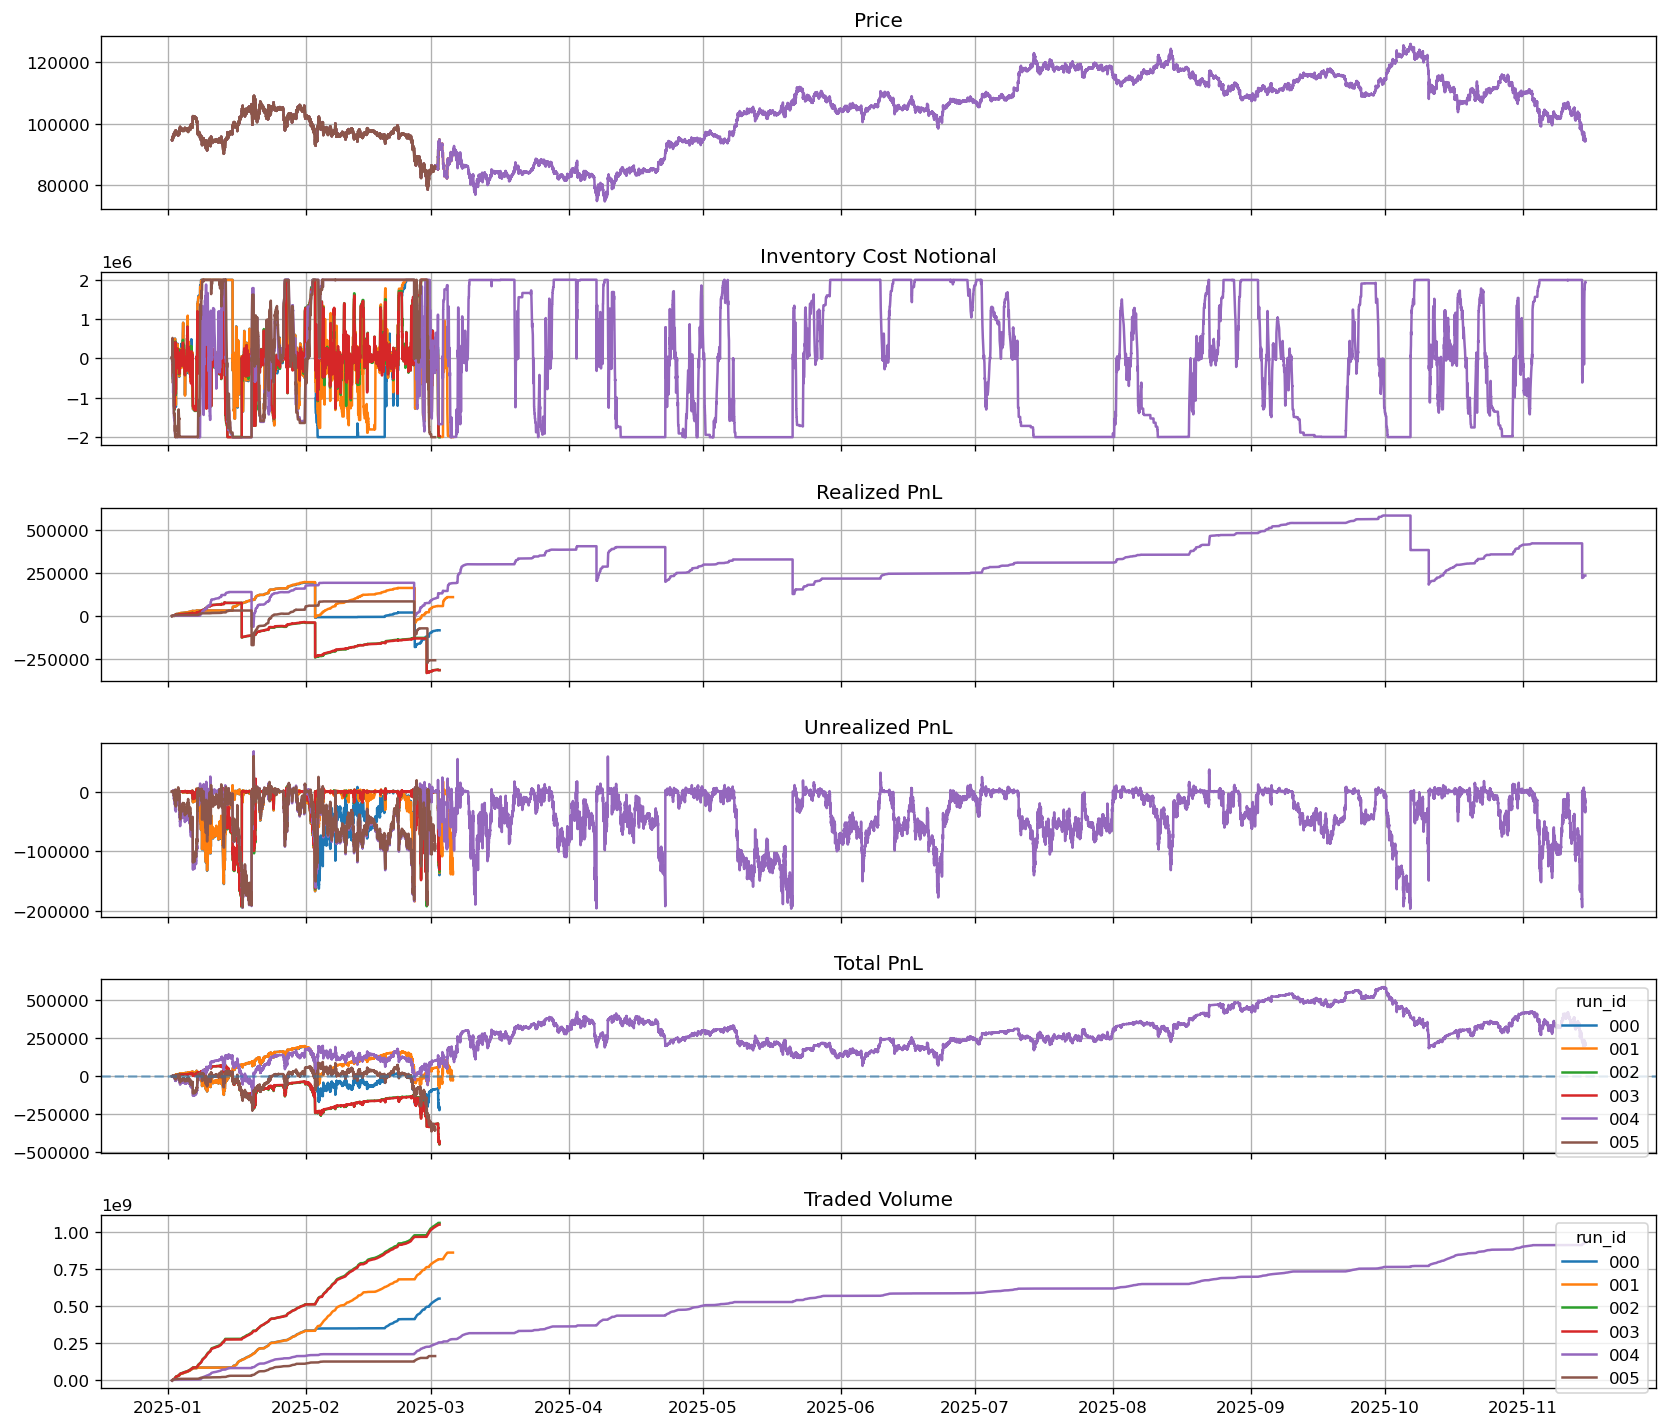

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,000,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...,-210900.369243,-0.079859,-3.429742,401592.485963,-1.377359e+06,-3.429742,-0.079859,8.928134e+06,-0.000382
1,001,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...,-24877.287708,-0.013942,-0.833023,259881.721106,-2.164876e+05,-0.833023,-0.013942,1.349357e+07,-0.000029
2,002,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...,-437037.456559,-0.229792,-5.430048,506522.057693,-2.750439e+06,-5.430048,-0.229792,1.752741e+07,-0.000412
3,003,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...,-434064.242281,-0.231553,-5.428084,503076.693828,-2.730742e+06,-5.428084,-0.231553,1.733228e+07,-0.000413
4,004,317,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,208390.181559,0.019572,0.664819,389212.269546,2.587557e+05,0.664819,0.019572,2.913412e+06,0.000225
5,005,59,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,-352803.330536,-0.128090,-5.018943,435799.181408,-2.187251e+06,-5.018943,-0.128090,2.681203e+06,-0.002147


batch 2: run_id 006..011


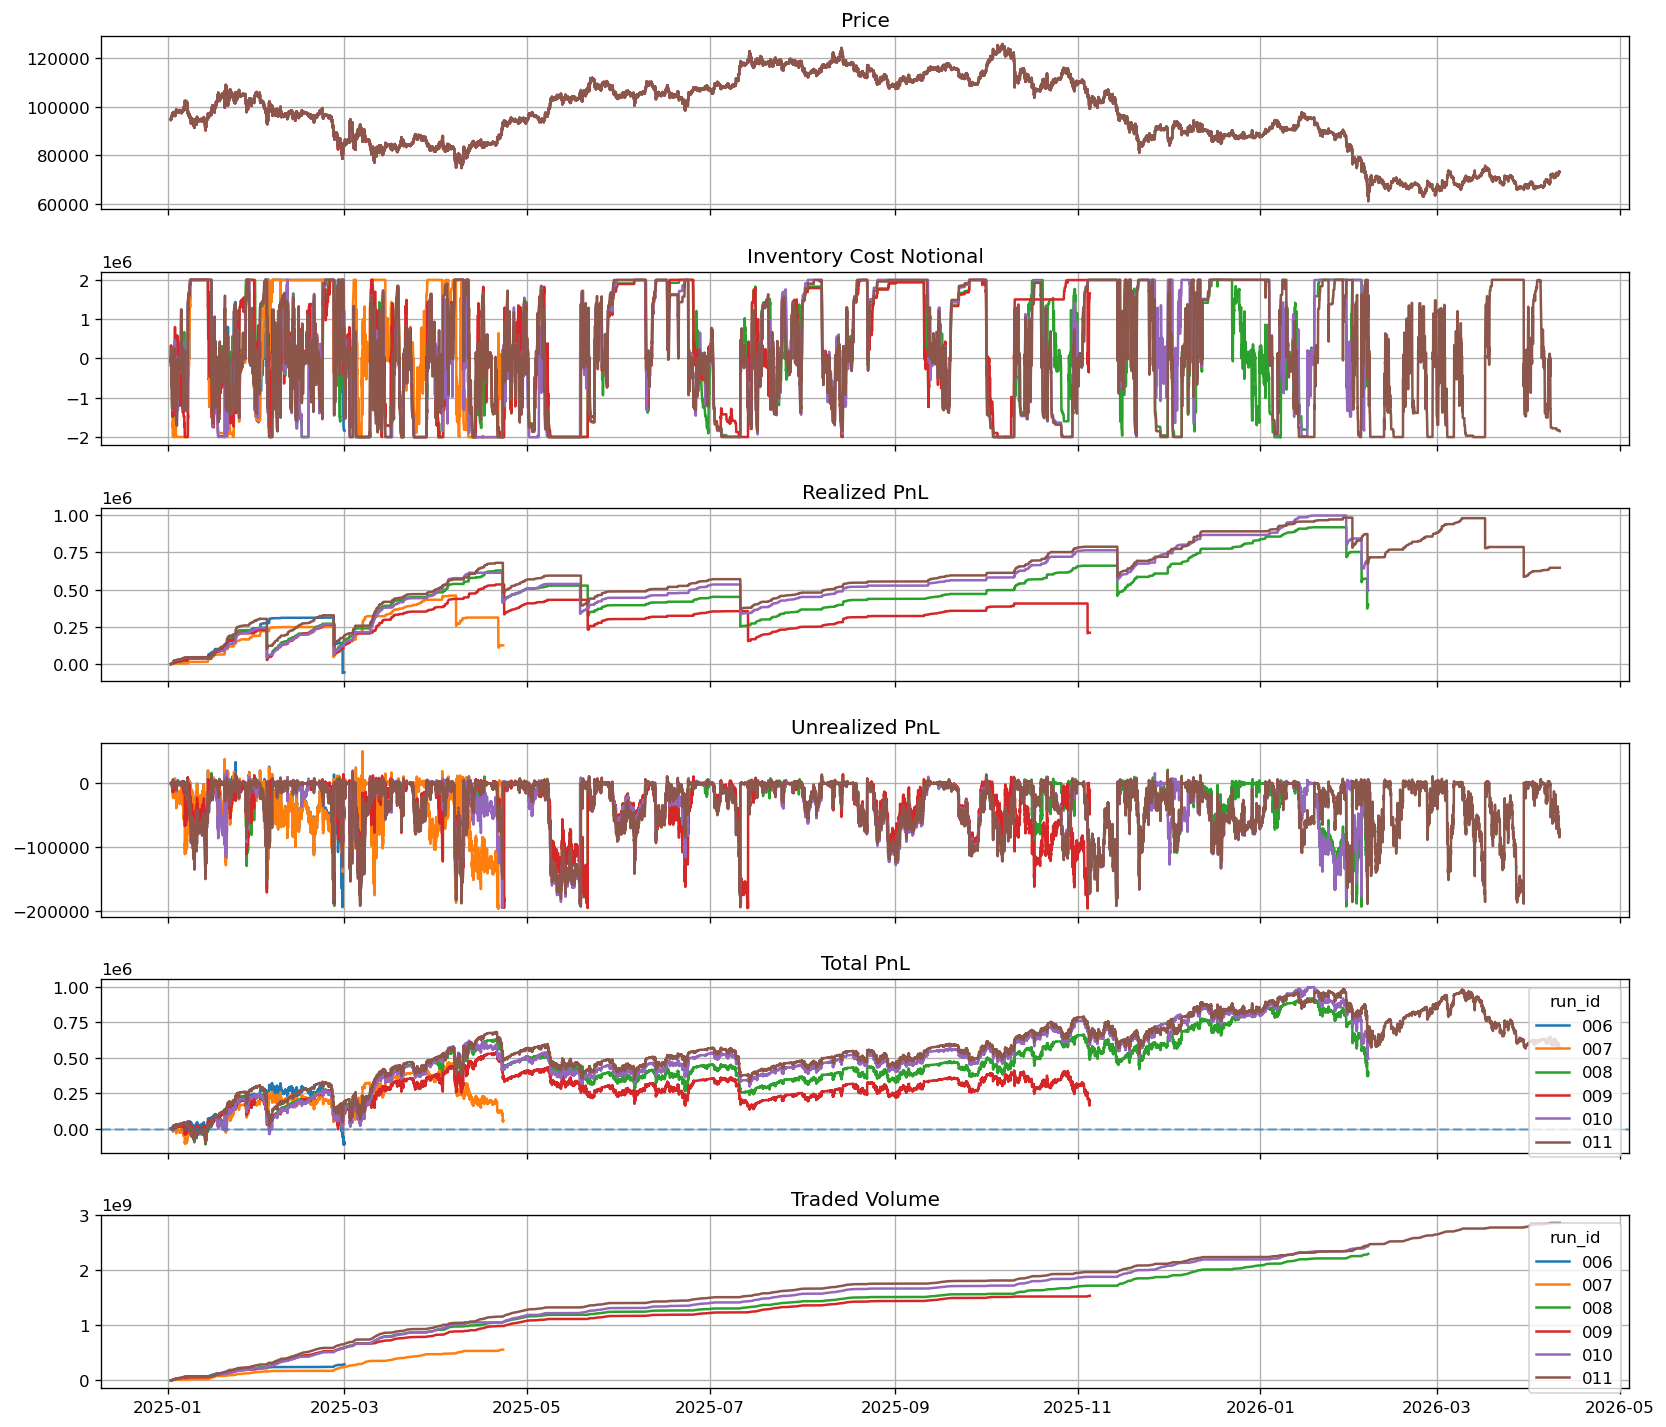

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,006,58,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,-104148.698858,-0.047944,-1.714303,408966.437105,-701092.434599,-1.714303,-0.047944,4.905455e+06,-0.000355
1,007,111,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,53354.700964,0.012815,0.484783,404890.710674,196284.284951,0.484783,0.012815,5.001646e+06,0.000095
2,008,400,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...,399206.023274,0.028201,0.692549,518485.071041,359076.347095,0.692549,0.028201,5.721648e+06,0.000174
3,009,307,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...,198084.505921,0.018258,0.609776,374651.652295,228453.593417,0.609776,0.018258,4.974242e+06,0.000129
4,010,400,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,492661.303184,0.031803,0.853626,504078.377552,430294.463194,0.853626,0.031803,6.052518e+06,0.000202
5,011,464,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,571443.854508,0.032332,1.059135,408770.373816,432943.210780,1.059135,0.032332,6.127334e+06,0.000200


batch 3: run_id 012..017


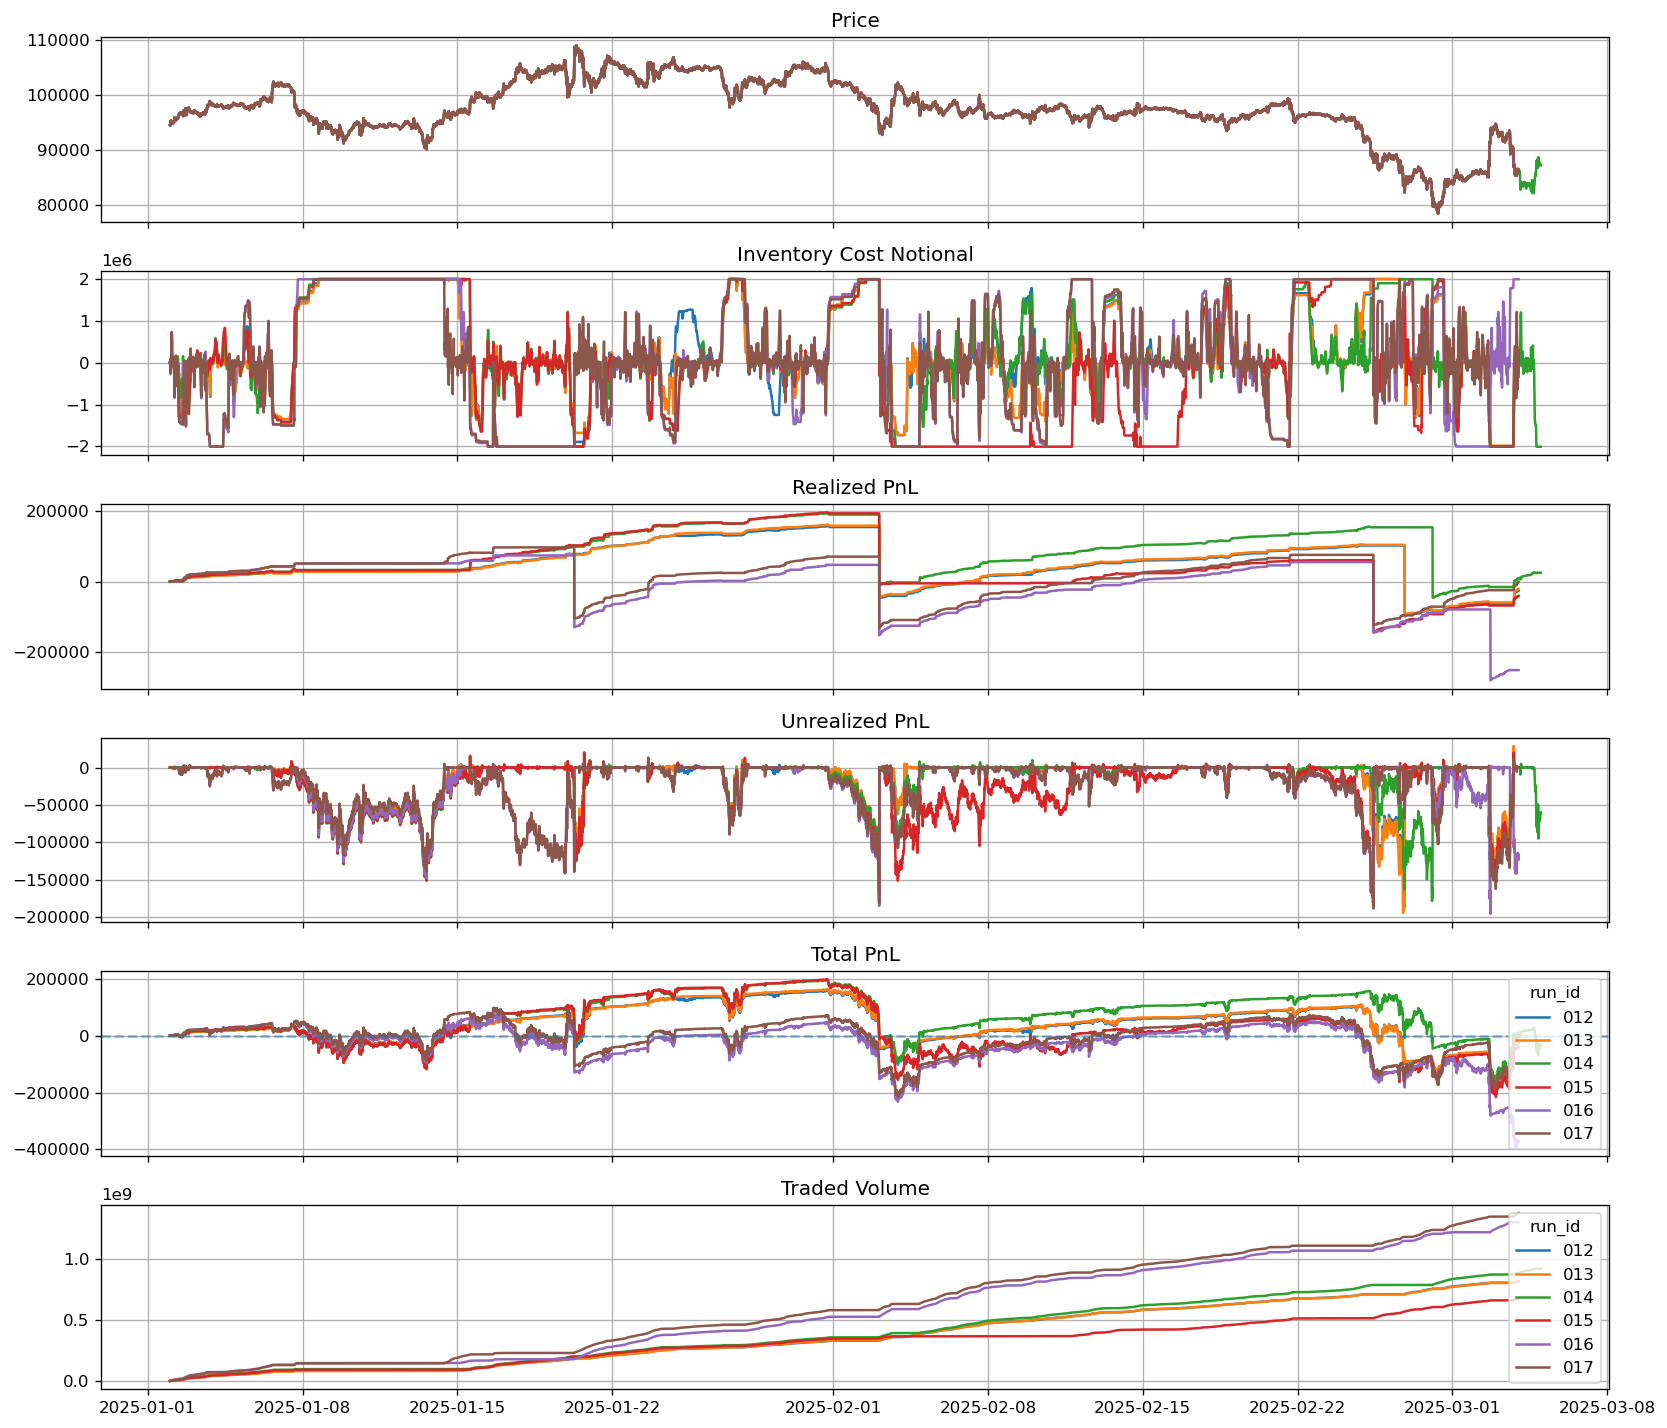

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,012,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...,-25955.801092,-0.015633,-0.694691,341094.506869,-2.369552e+05,-0.694691,-0.015633,1.323859e+07,-3.171245e-05
1,013,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...,-21273.959965,-0.013655,-0.605245,337564.634870,-2.043092e+05,-0.605245,-0.013655,1.320023e+07,-2.607698e-05
2,014,62,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,-34443.453988,-0.017971,-0.855960,343962.024843,-2.944177e+05,-0.855960,-0.017971,1.464894e+07,-3.728801e-05
3,015,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,-40377.410316,-0.018875,-0.859508,397290.619429,-3.414744e+05,-0.859508,-0.018875,1.081911e+07,-5.976205e-05
4,016,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-374247.020338,-0.138228,-5.505319,436389.416877,-2.402463e+06,-5.505319,-0.138228,2.093639e+07,-2.870590e-04
5,017,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-60.585175,-0.006447,-0.434136,283057.447501,-1.228853e+05,-0.434136,-0.006447,2.224391e+07,-4.388512e-08


batch 4: run_id 018..023


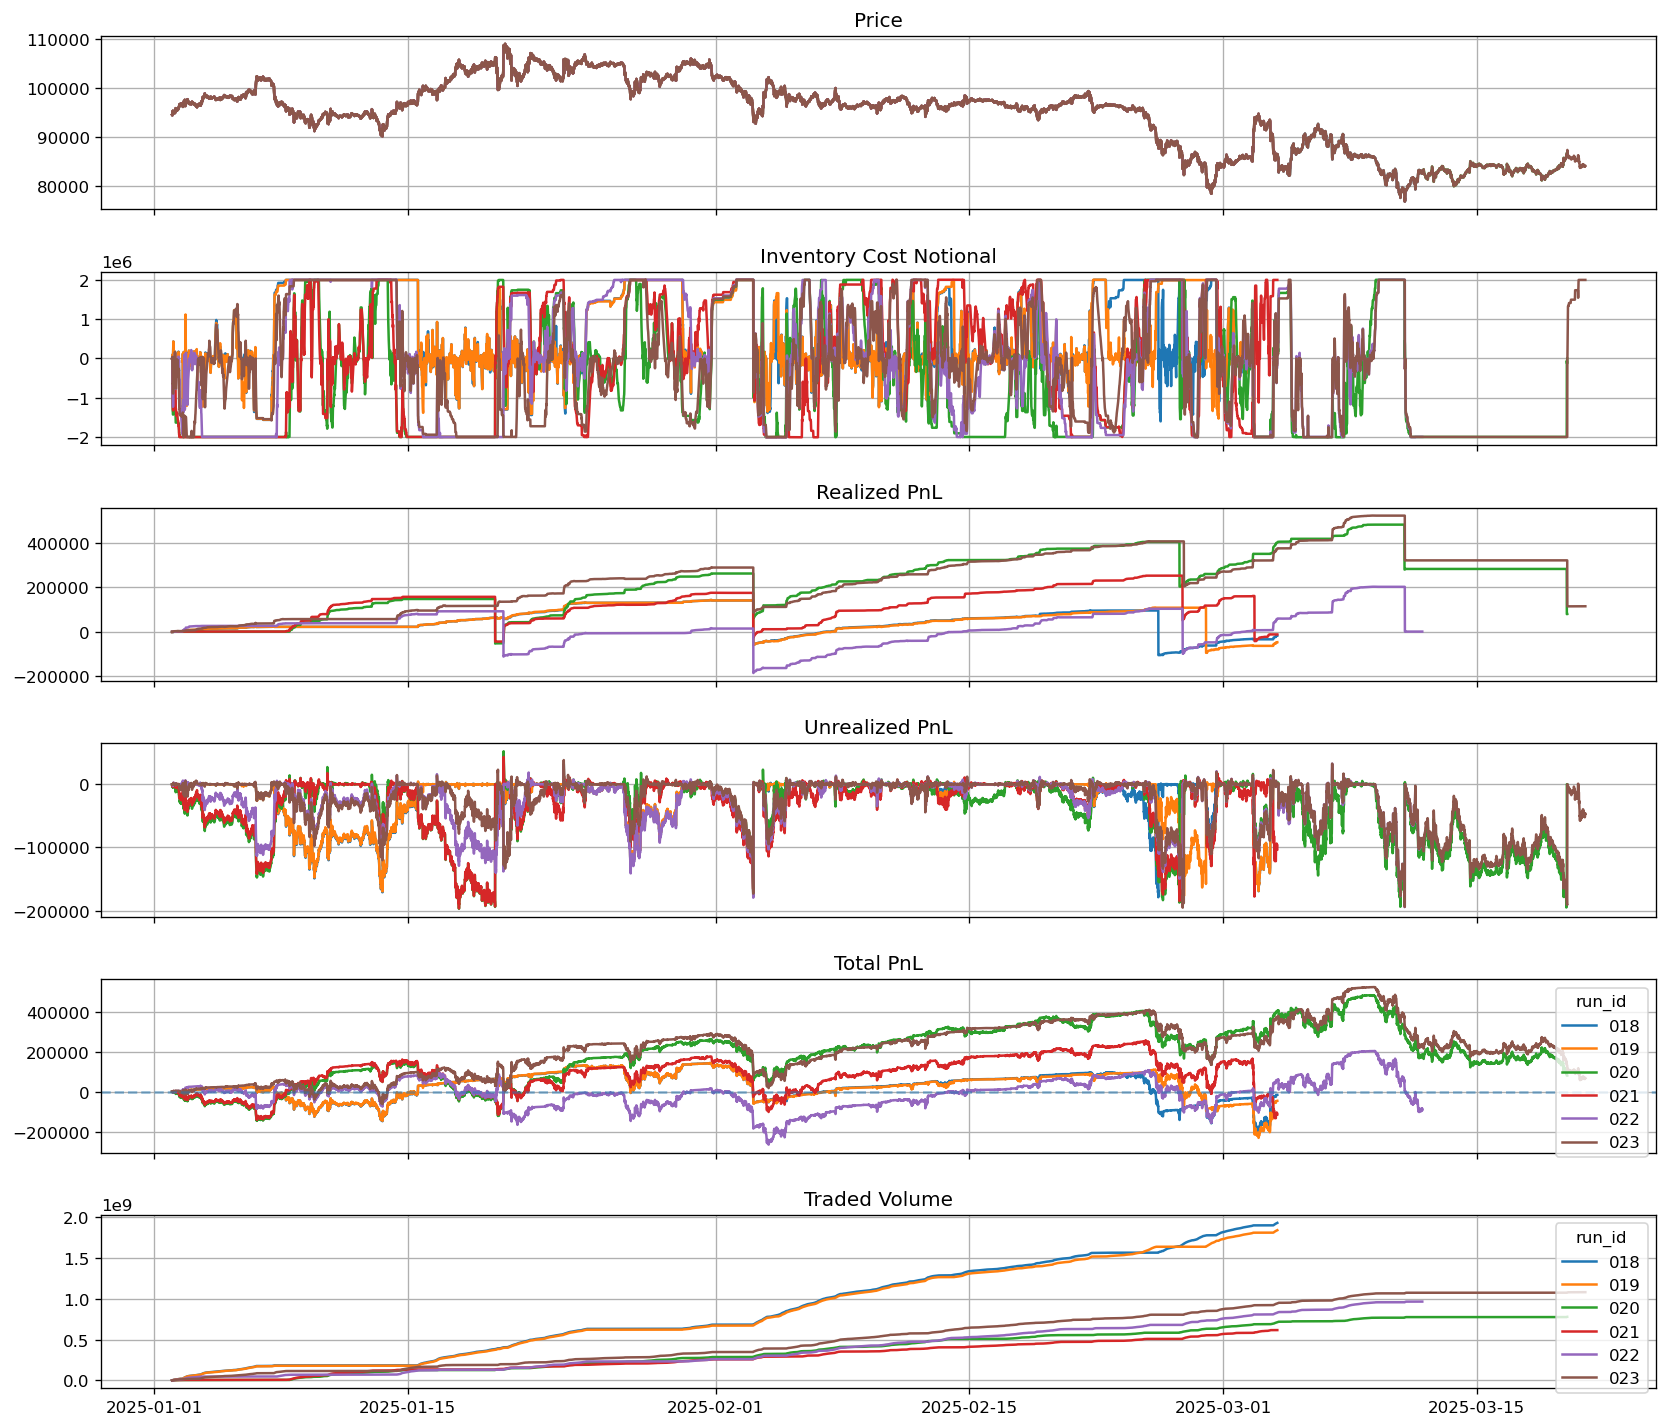

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,018,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-16322.377904,-0.009671,-0.450220,329323.003040,-148267.739257,-0.450220,-0.009671,3.124509e+07,-0.000008
1,019,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-46198.467045,-0.022473,-0.939050,358503.624591,-336652.919683,-0.939050,-0.022473,2.976376e+07,-0.000025
2,020,77,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,80260.487108,0.027448,1.347518,401978.576004,541673.473179,1.347518,0.027448,1.019038e+07,0.000103
3,021,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-114330.806573,-0.028710,-1.515492,353618.135036,-535905.429063,-1.515492,-0.028710,1.017510e+07,-0.000185
4,022,69,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-91709.244889,-0.028406,-1.898629,327934.974955,-622626.829344,-1.898629,-0.028406,1.371034e+07,-0.000095
5,023,78,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,68244.606426,0.016276,0.682005,454057.130753,309669.362275,0.682005,0.016276,1.381090e+07,0.000063


batch 5: run_id 024..029


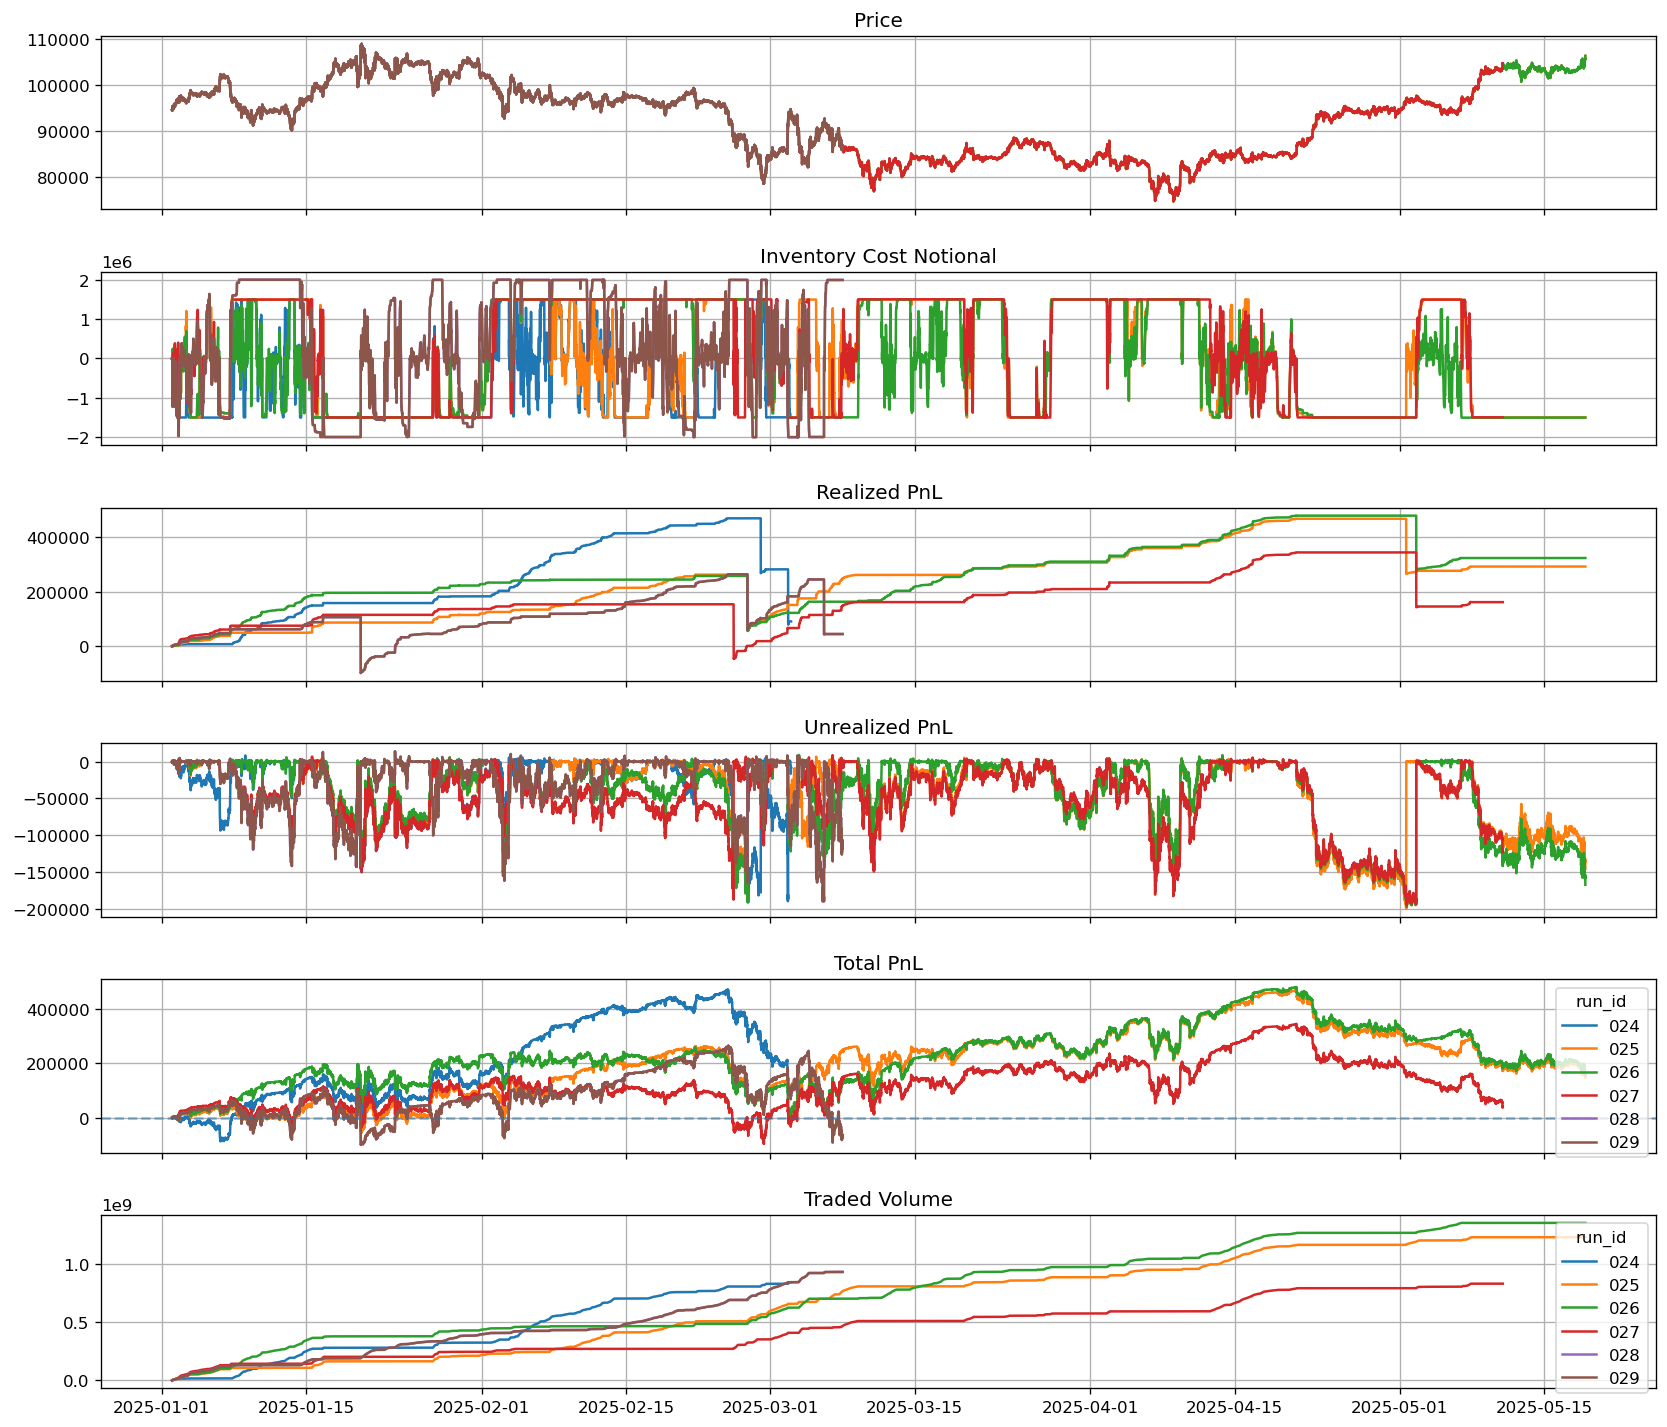

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,024,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp15000...,82758.741110,0.040760,1.461308,368809.592617,538944.486479,1.461308,0.040760,1.399338e+07,0.000098
1,025,137,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp15000...,146510.755126,0.029635,1.130648,319655.956602,361418.447140,1.130648,0.029635,8.796882e+06,0.000119
2,026,137,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp15000...,156008.711722,0.028858,1.154834,322370.295879,372284.316247,1.154834,0.028858,9.677389e+06,0.000116
3,027,129,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp15000...,38756.063329,0.002723,0.117540,305040.101704,35854.492531,0.117540,0.002723,6.124537e+06,0.000047
4,028,65,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-62382.744508,-0.027881,-1.465563,304453.226745,-446195.266434,-1.465563,-0.027881,1.402316e+07,-0.000067
5,029,65,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-62382.744508,-0.027881,-1.465563,304453.226745,-446195.266434,-1.465563,-0.027881,1.402316e+07,-0.000067


batch 6: run_id 030..035


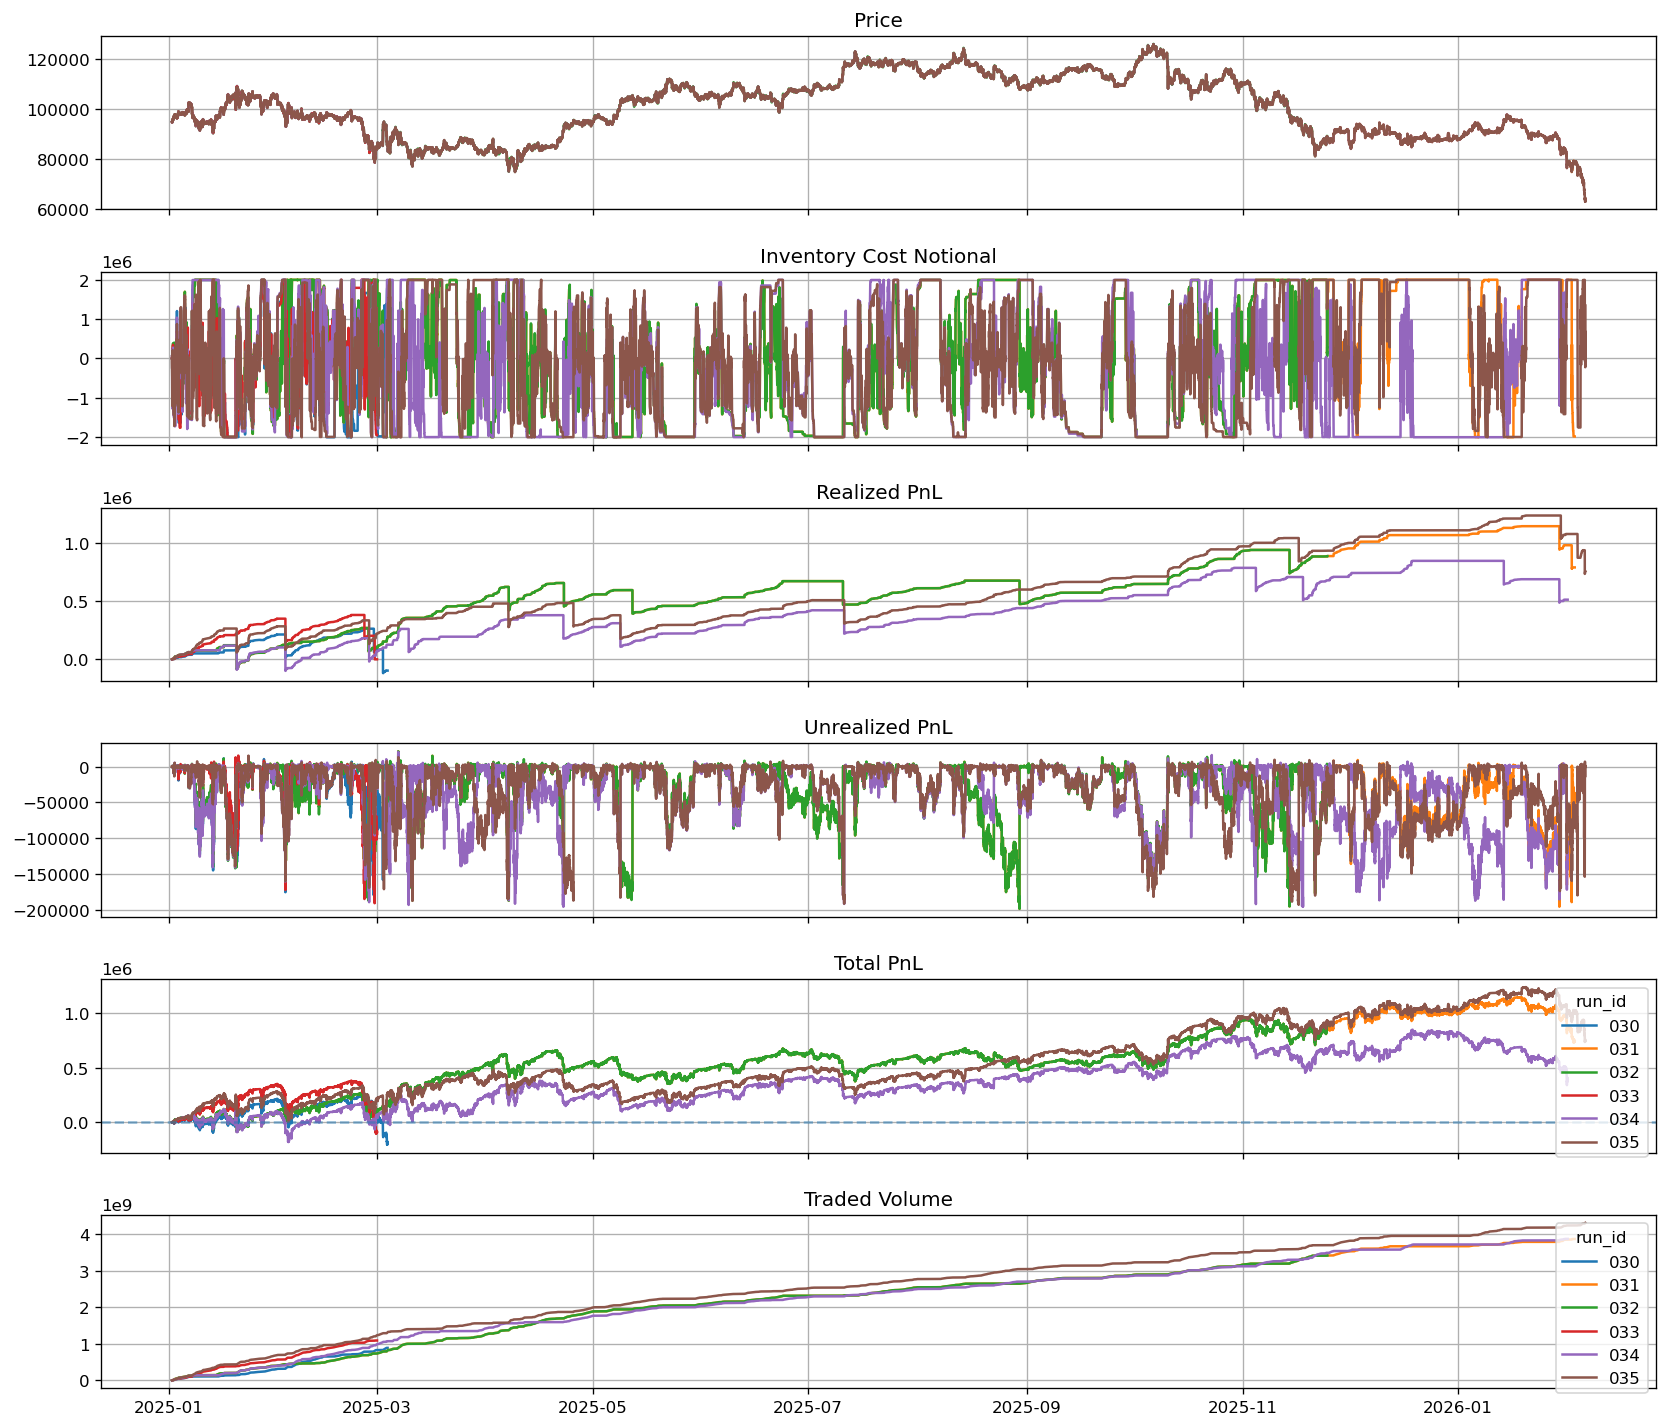

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,030,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-185789.647838,-0.077353,-2.753133,436694.860004,-1.202279e+06,-2.753133,-0.077353,1.436471e+07,-0.000208
1,031,397,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,737496.797831,0.050720,1.637753,400189.968148,6.554124e+05,1.637753,0.050720,9.668553e+06,0.000190
2,032,326,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,880291.130594,0.074669,3.238797,295178.150713,9.560222e+05,3.238797,0.074669,1.035506e+07,0.000257
3,033,58,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-90910.354967,-0.039020,-1.502041,461947.696718,-6.938643e+05,-1.502041,-0.039020,1.861279e+07,-0.000083
4,034,395,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,398462.770410,0.024906,0.780537,444768.429639,3.471584e+05,0.780537,0.024906,9.756206e+06,0.000103
5,035,400,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,741955.376532,0.045889,1.347836,487653.860901,6.572776e+05,1.347836,0.045889,1.072284e+07,0.000172


batch 7: run_id 036..041


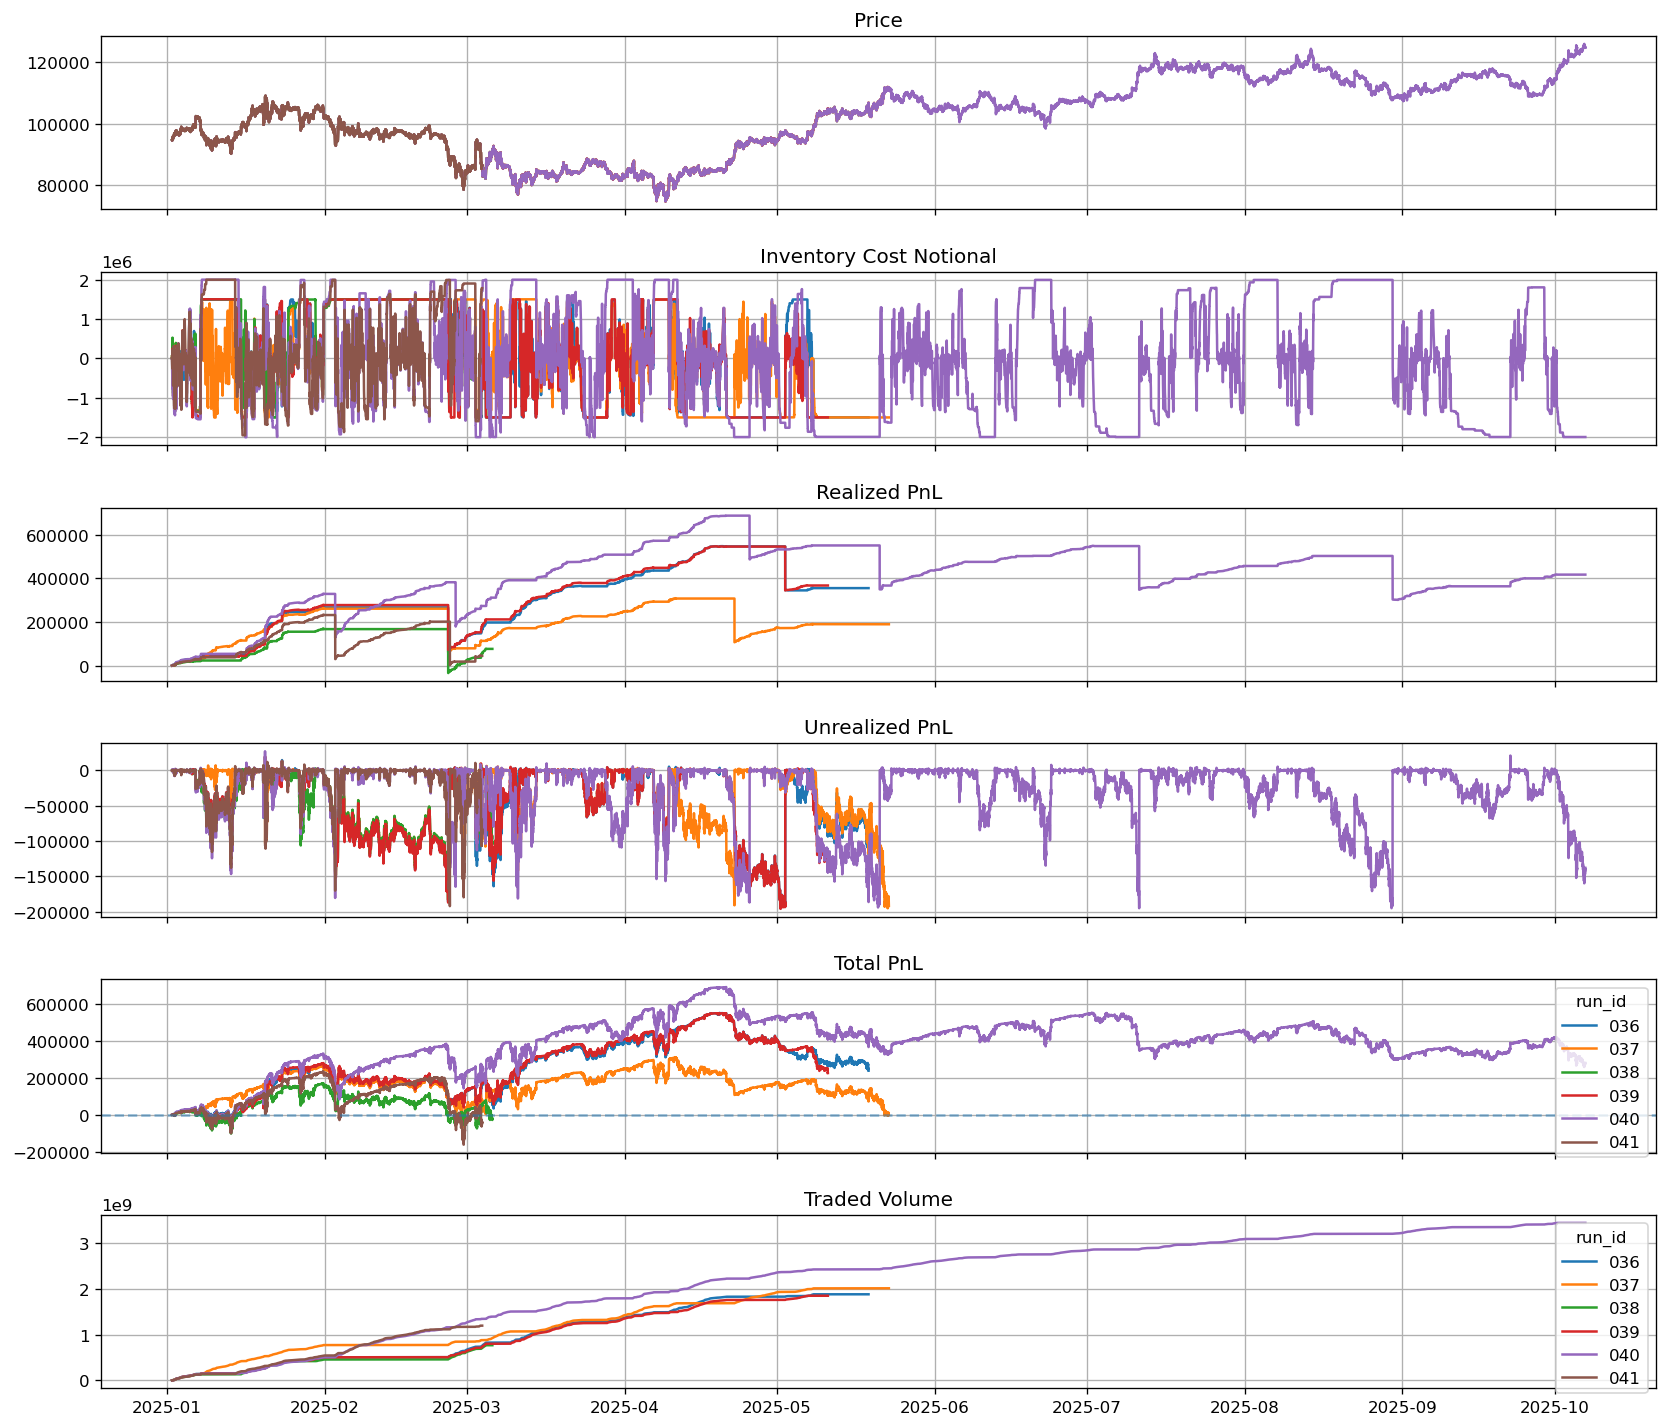

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,036,137,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp1500...,237571.164063,0.049621,1.925945,310654.966346,598304.284854,1.925945,0.049621,1.349703e+07,1.264183e-04
1,037,141,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp1500...,-1962.585906,-0.003082,-0.097814,309002.926321,-30224.912981,-0.097814,-0.003082,1.406894e+07,-9.764132e-07
2,038,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp1500...,-25215.199927,-0.017196,-0.869358,228261.803529,-198441.164739,-0.869358,-0.017196,1.175709e+07,-3.280791e-05
3,039,129,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp1500...,225224.581696,0.050292,1.883997,322689.111439,607945.375015,1.883997,0.050292,1.409443e+07,1.219212e-04
4,040,278,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,279626.891239,0.028232,0.846983,409177.161052,346566.151240,0.846983,0.028232,1.225742e+07,8.136164e-05
5,041,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-45156.425068,-0.026009,-1.252155,271336.788722,-339755.644509,-1.252155,-0.026009,1.926436e+07,-3.778171e-05


batch 8: run_id 042..047


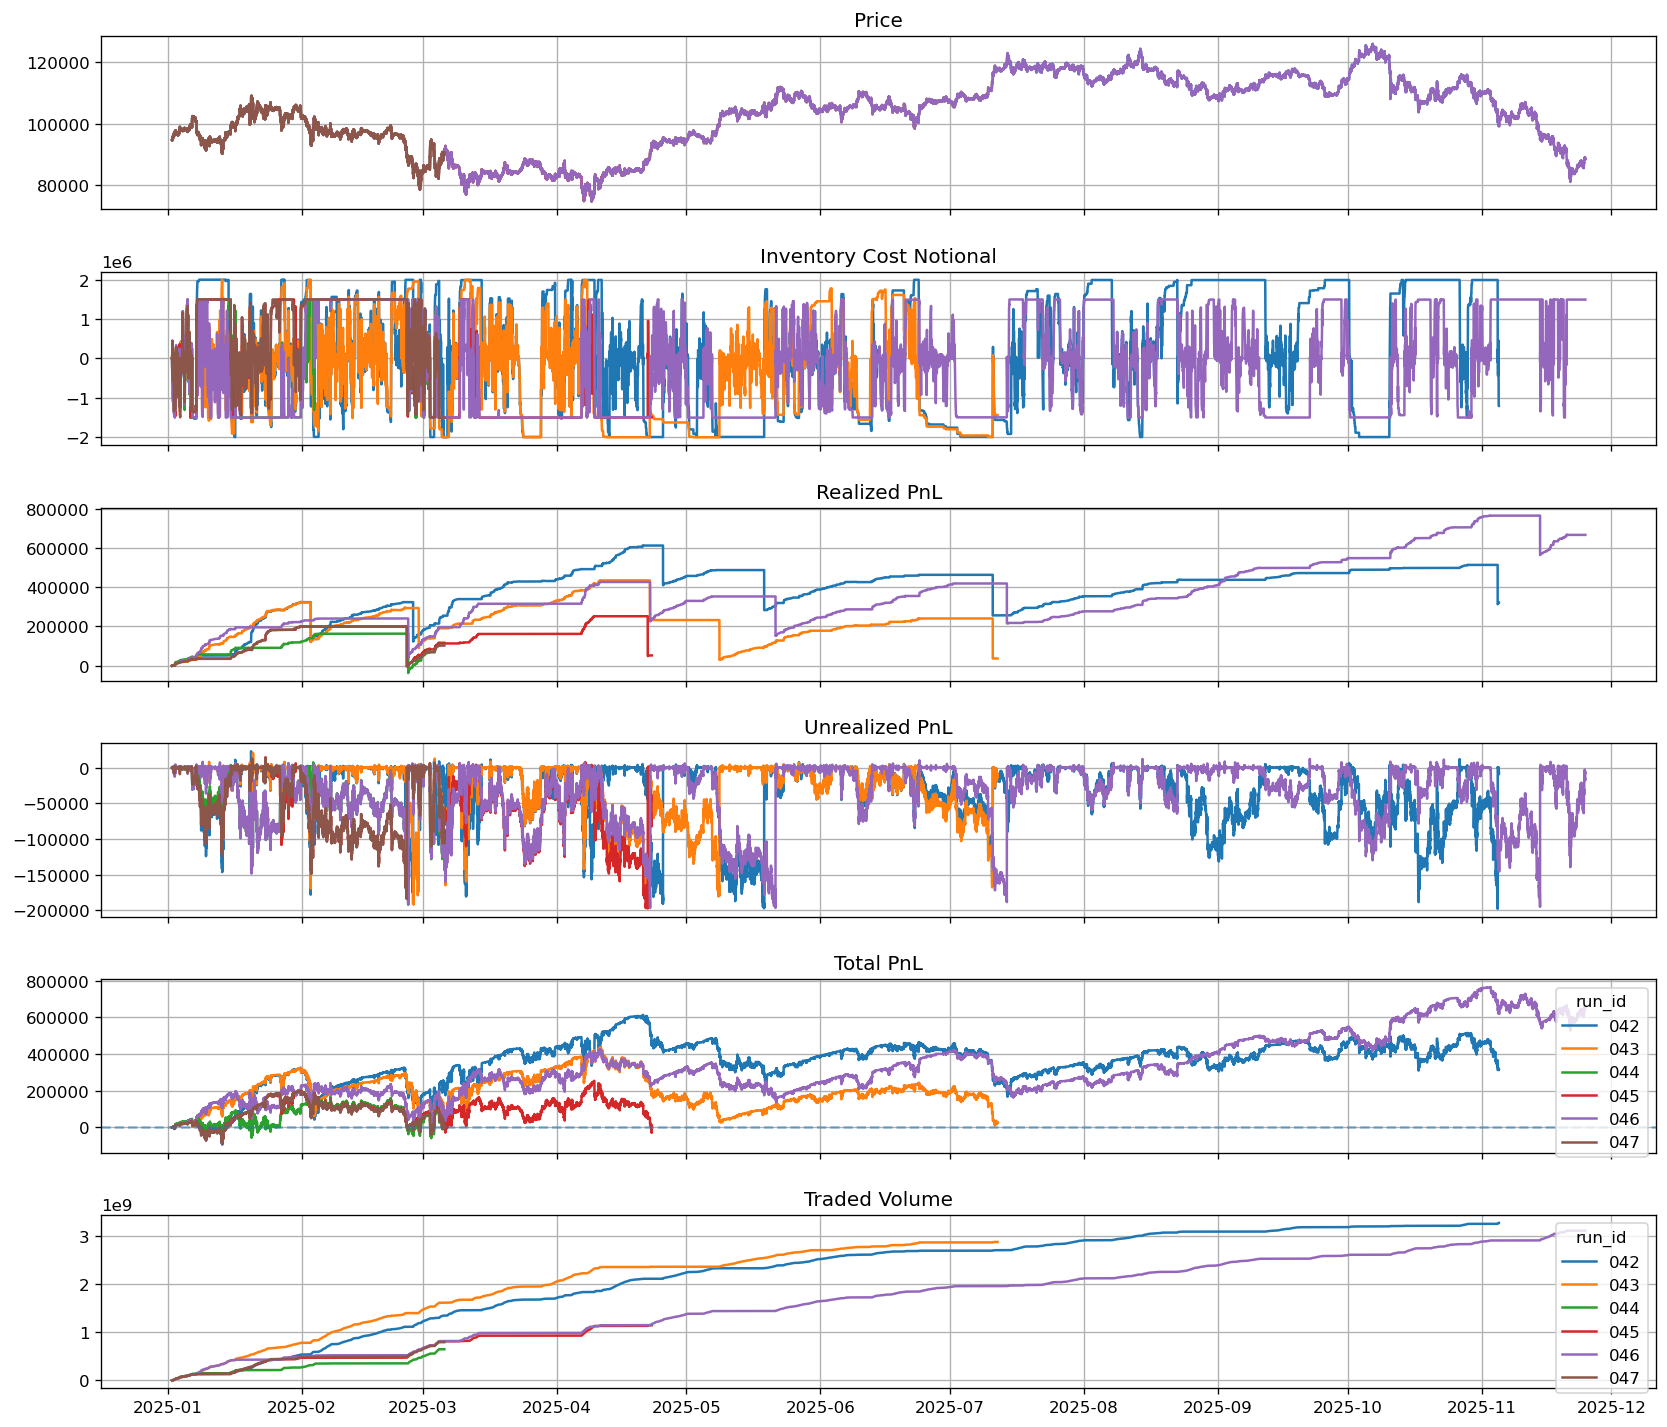

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,042,307,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,313888.691155,0.028724,0.901093,395942.663621,356781.252664,0.901093,0.028724,1.054051e+07,9.611691e-05
1,043,191,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,26010.048811,0.002187,0.064728,407060.865131,26348.102140,0.064728,0.002187,1.490350e+07,9.061284e-06
2,044,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp15000...,-7854.029569,-0.012123,-0.767158,209365.580256,-160616.413748,-0.767158,-0.012123,9.767825e+06,-1.214665e-05
3,045,111,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp15000...,-25513.655848,-0.009778,-0.480114,262277.079663,-125922.973003,-0.480114,-0.009778,1.009824e+07,-2.227683e-05
4,046,326,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp15000...,649161.591438,0.069000,2.682009,265134.423513,711092.834018,2.682009,0.069000,9.415584e+06,2.091102e-04
5,047,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp15000...,-353.947399,-0.006259,-0.320879,224557.203419,-72055.741686,-0.320879,-0.006259,1.217204e+07,-4.460021e-07


batch 9: run_id 048..053


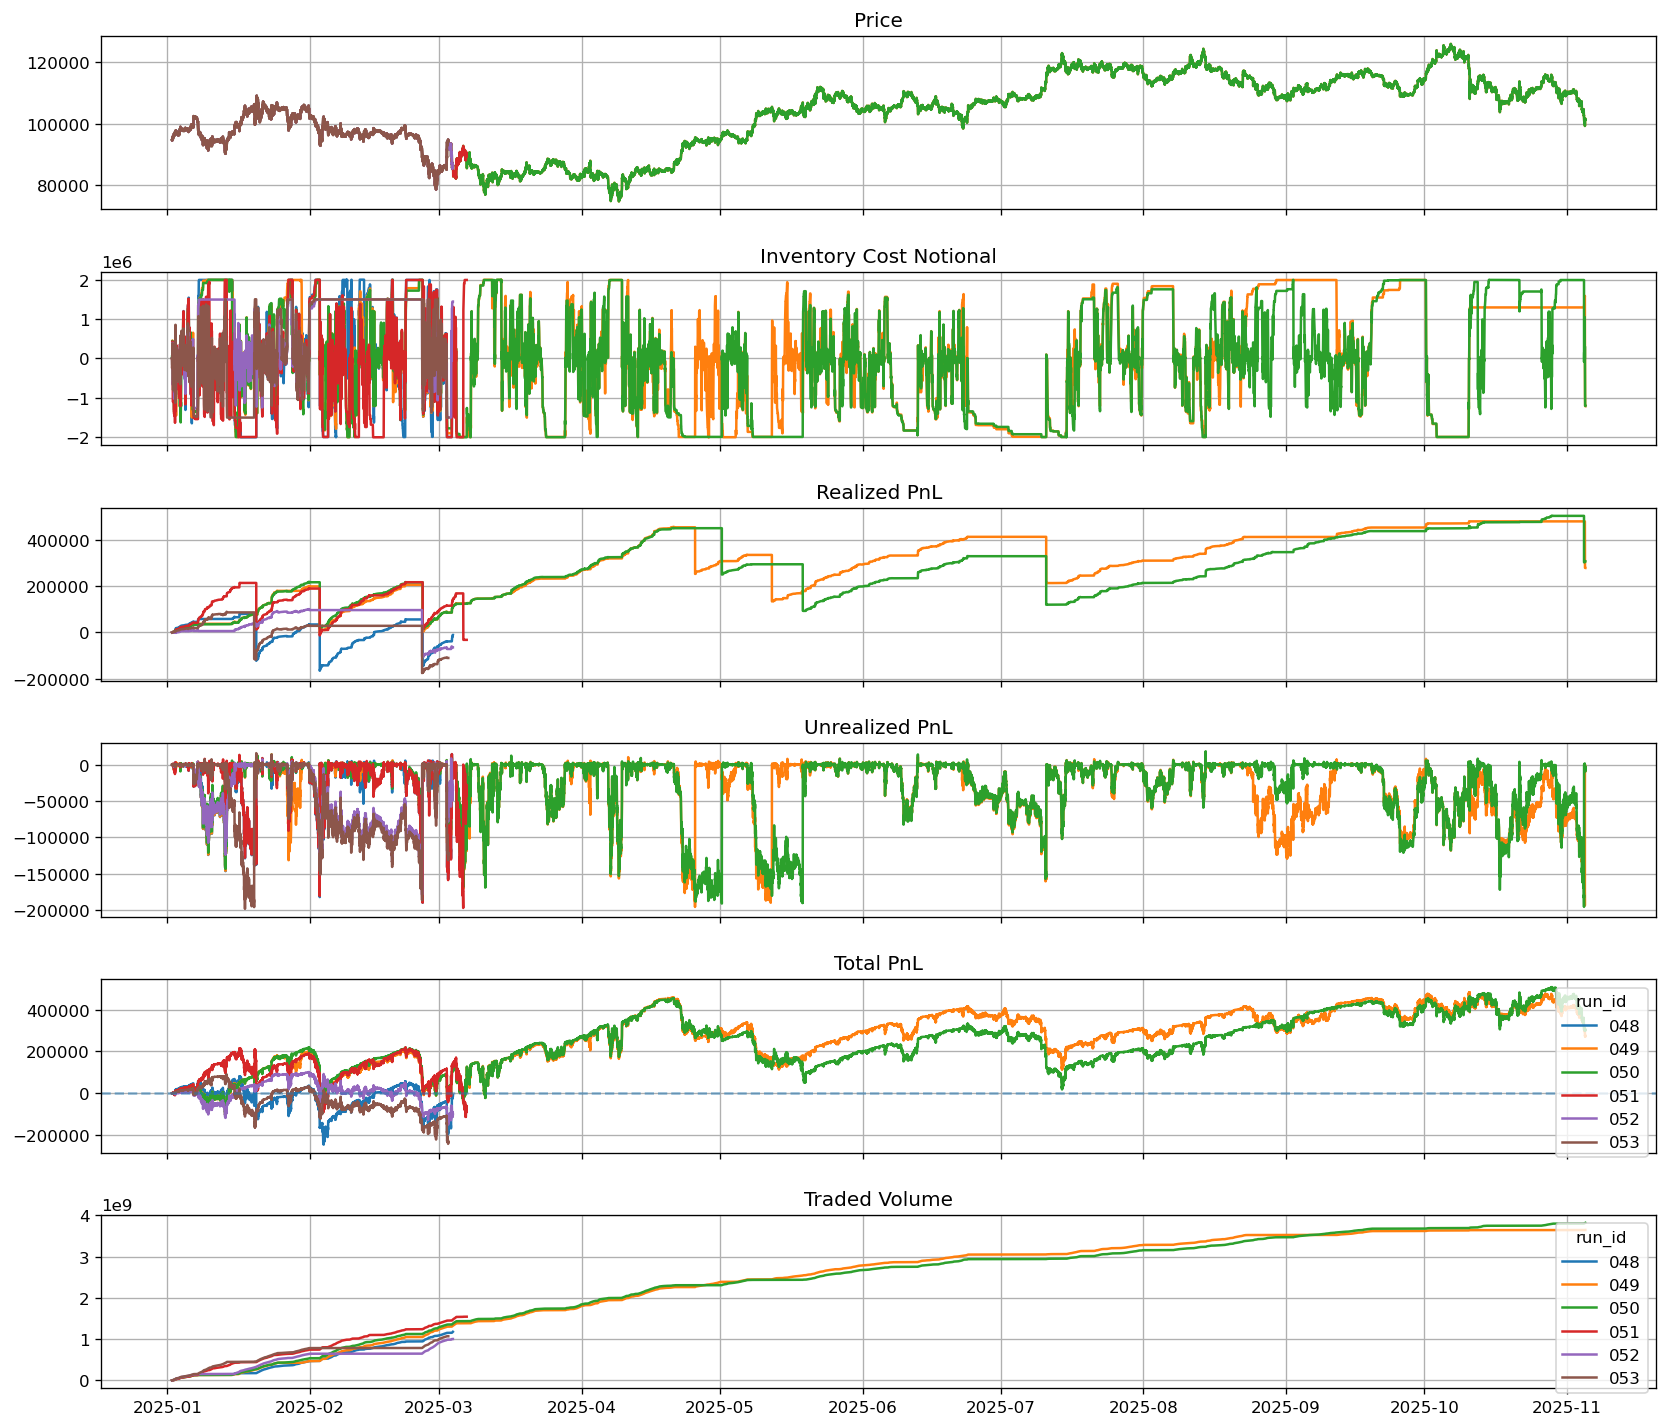

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,048,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-10264.209494,-0.009815,-0.609594,296315.676111,-1.806322e+05,-0.609594,-0.009815,1.897112e+07,-0.000009
1,049,307,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,271695.935545,0.025861,0.935419,330598.724117,3.092483e+05,0.935419,0.025861,1.180747e+07,0.000074
2,050,307,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,300586.660204,0.029103,0.901636,381933.986117,3.443656e+05,0.901636,0.029103,1.235172e+07,0.000079
3,051,64,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-73473.407749,-0.026617,-1.801677,281385.413029,-5.069655e+05,-1.801677,-0.026617,2.395709e+07,-0.000048
4,052,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp1500...,-99361.329700,-0.070437,-2.542407,238254.698421,-6.057404e+05,-2.542407,-0.070437,1.594462e+07,-0.000099
5,053,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp1500...,-232371.758680,-0.130260,-4.756677,312214.623686,-1.485104e+06,-4.756677,-0.130260,1.728896e+07,-0.000217


batch 10: run_id 054..059


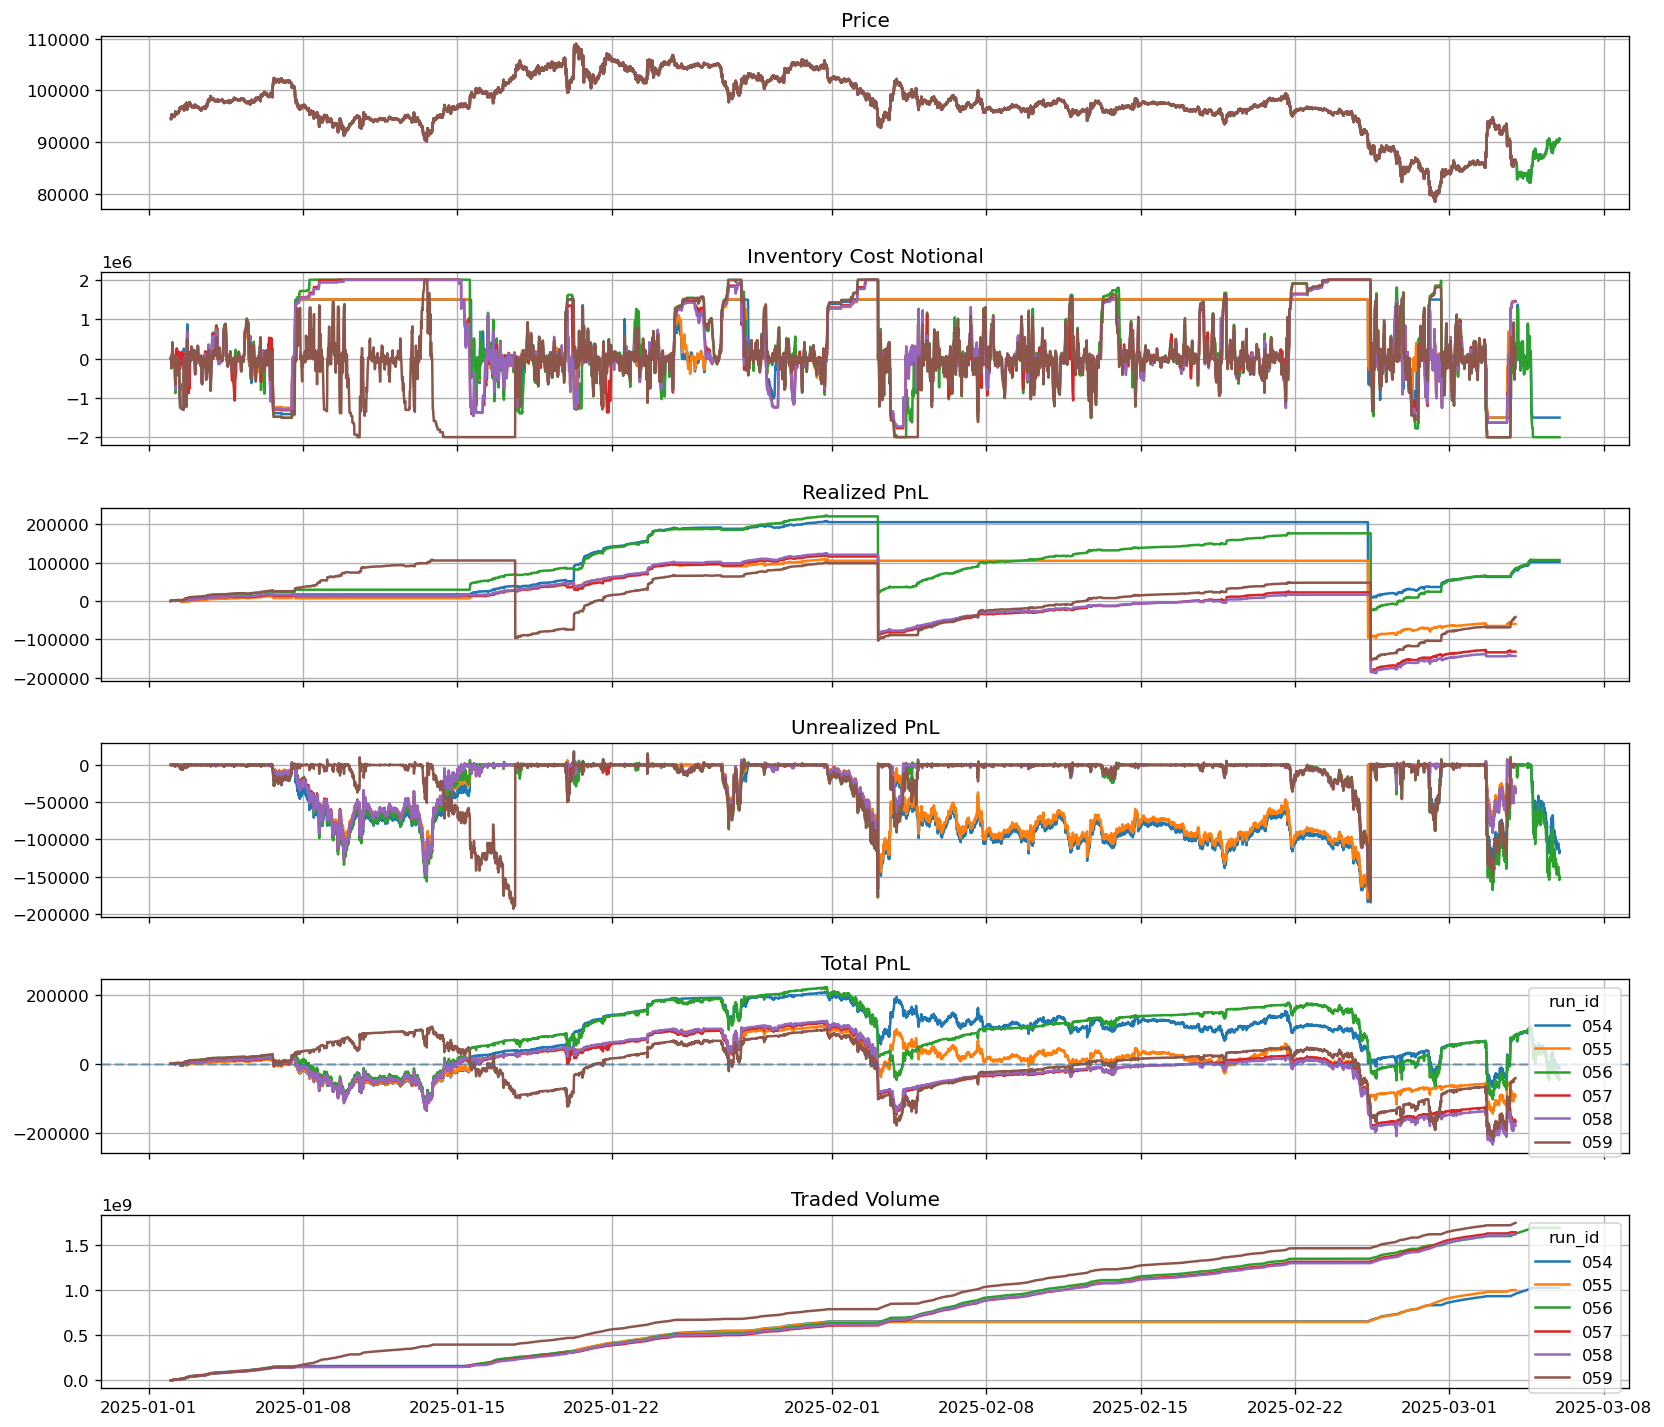

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,054,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp1500...,-13844.790679,-0.008147,-0.400216,262017.837441,-1.048637e+05,-0.400216,-0.008147,1.567560e+07,-0.000014
1,055,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp1500...,-94669.021303,-0.066442,-2.386621,241163.780093,-5.755664e+05,-2.386621,-0.066442,1.585237e+07,-0.000095
2,056,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-43651.466014,-0.018322,-1.007359,308141.008646,-3.104087e+05,-1.007359,-0.018322,2.648601e+07,-0.000026
3,057,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-169174.408661,-0.083159,-3.195901,329930.989990,-1.054427e+06,-3.195901,-0.083159,2.650879e+07,-0.000103
4,058,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-180277.513790,-0.089354,-3.250460,345363.896371,-1.122591e+06,-3.250460,-0.089354,2.619245e+07,-0.000112
5,059,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk40x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-41699.478543,-0.018471,-1.048397,302439.193102,-3.170763e+05,-1.048397,-0.018471,2.827539e+07,-0.000024


batch 11: run_id 060..065


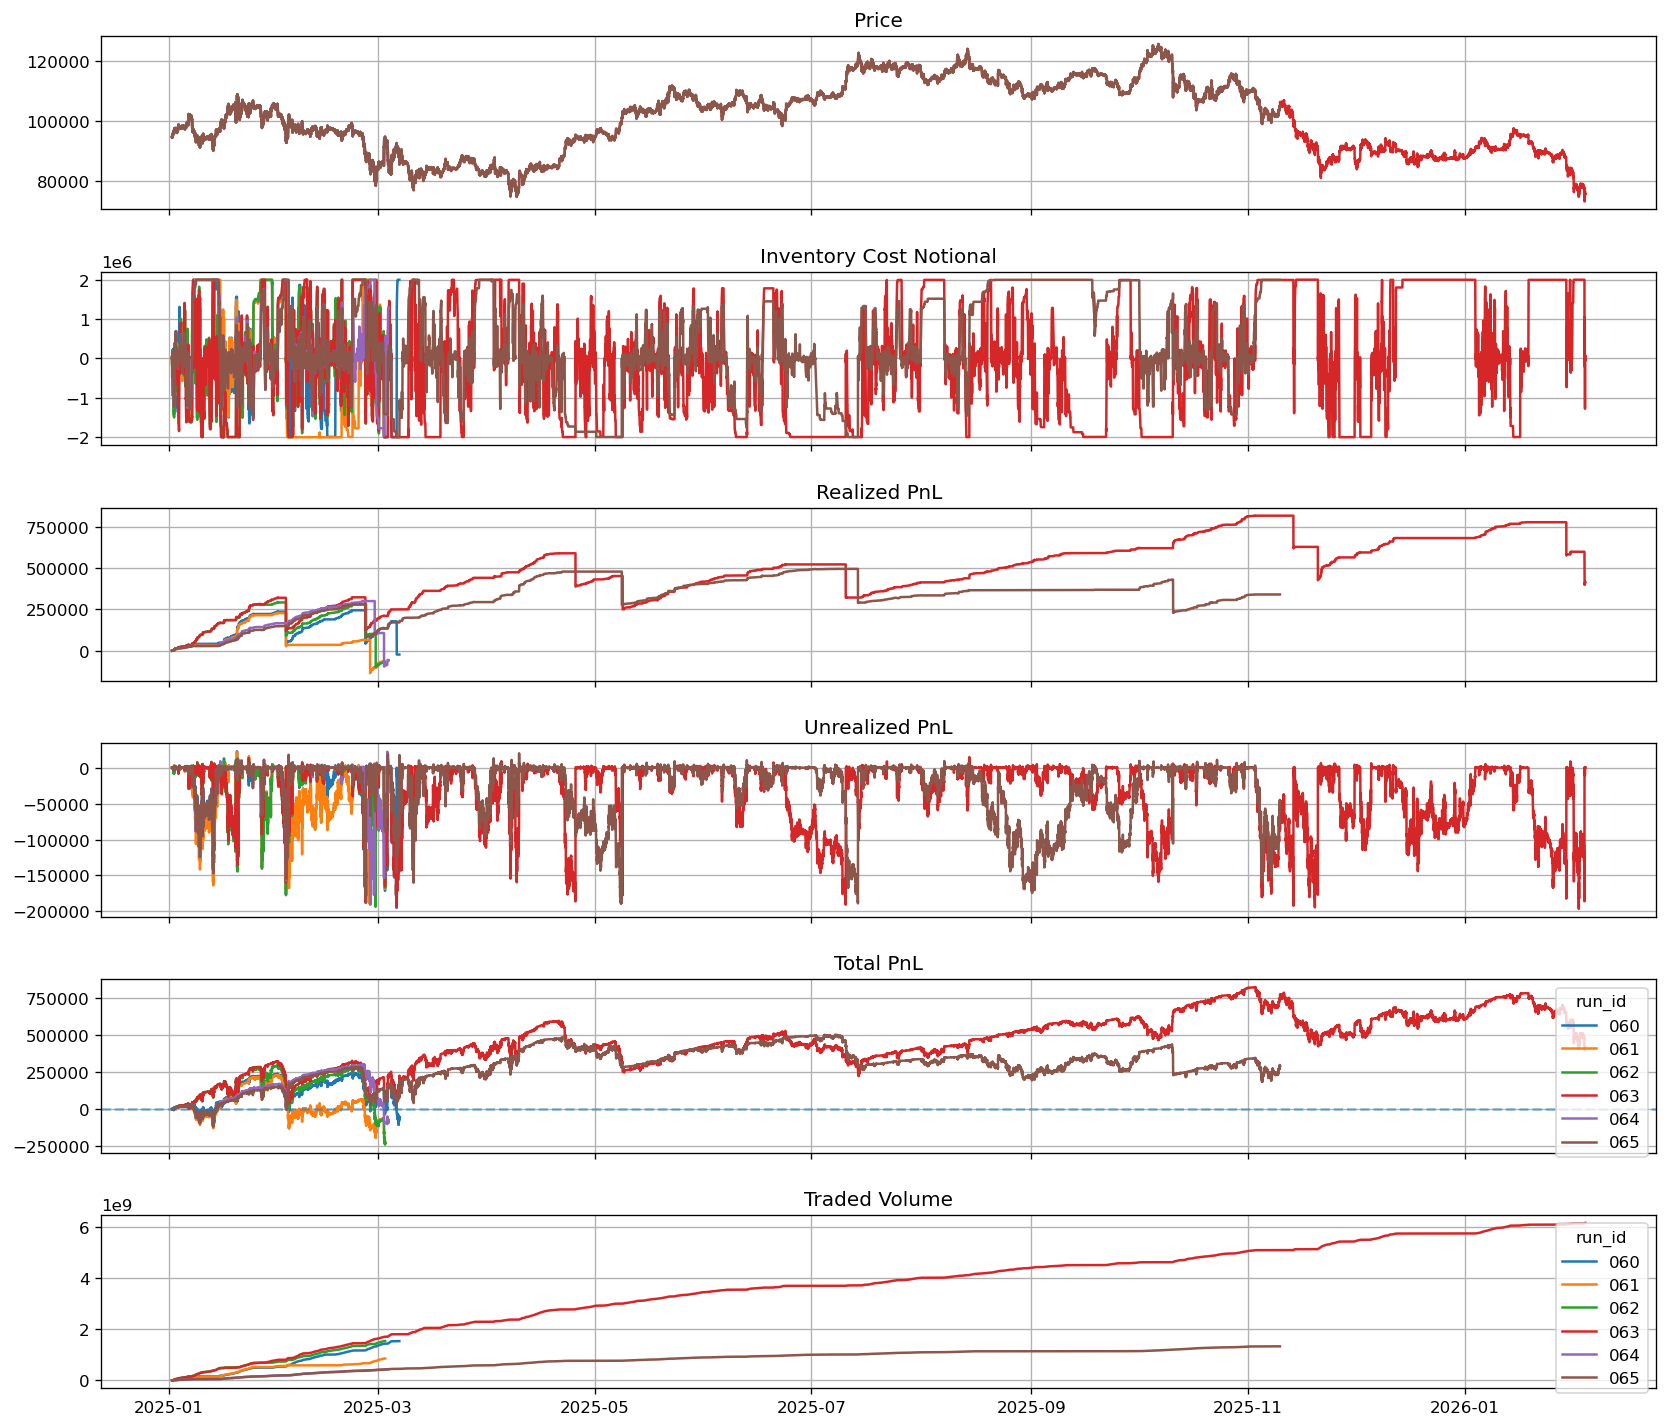

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,060,64,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-65408.261149,-0.024929,-1.520196,302156.755859,-4.593374e+05,-1.520196,-0.024929,2.374825e+07,-0.000043
1,061,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-221280.609098,-0.079095,-3.256862,445265.369912,-1.450168e+06,-3.256862,-0.079095,1.383861e+07,-0.000257
2,062,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-227237.369407,-0.085850,-2.884660,514674.341290,-1.484660e+06,-2.884660,-0.085850,2.534868e+07,-0.000147
3,063,398,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,415668.262586,0.029370,0.912900,404952.106195,3.696810e+05,0.912900,0.029370,1.539414e+07,0.000067
4,064,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-80787.286418,-0.049390,-1.418055,386457.861124,-5.480183e+05,-1.418055,-0.049390,7.030869e+06,-0.000186
5,065,312,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,287660.891505,0.031282,1.140042,286838.413146,3.270077e+05,1.140042,0.031282,4.252498e+06,0.000215


batch 12: run_id 066..071


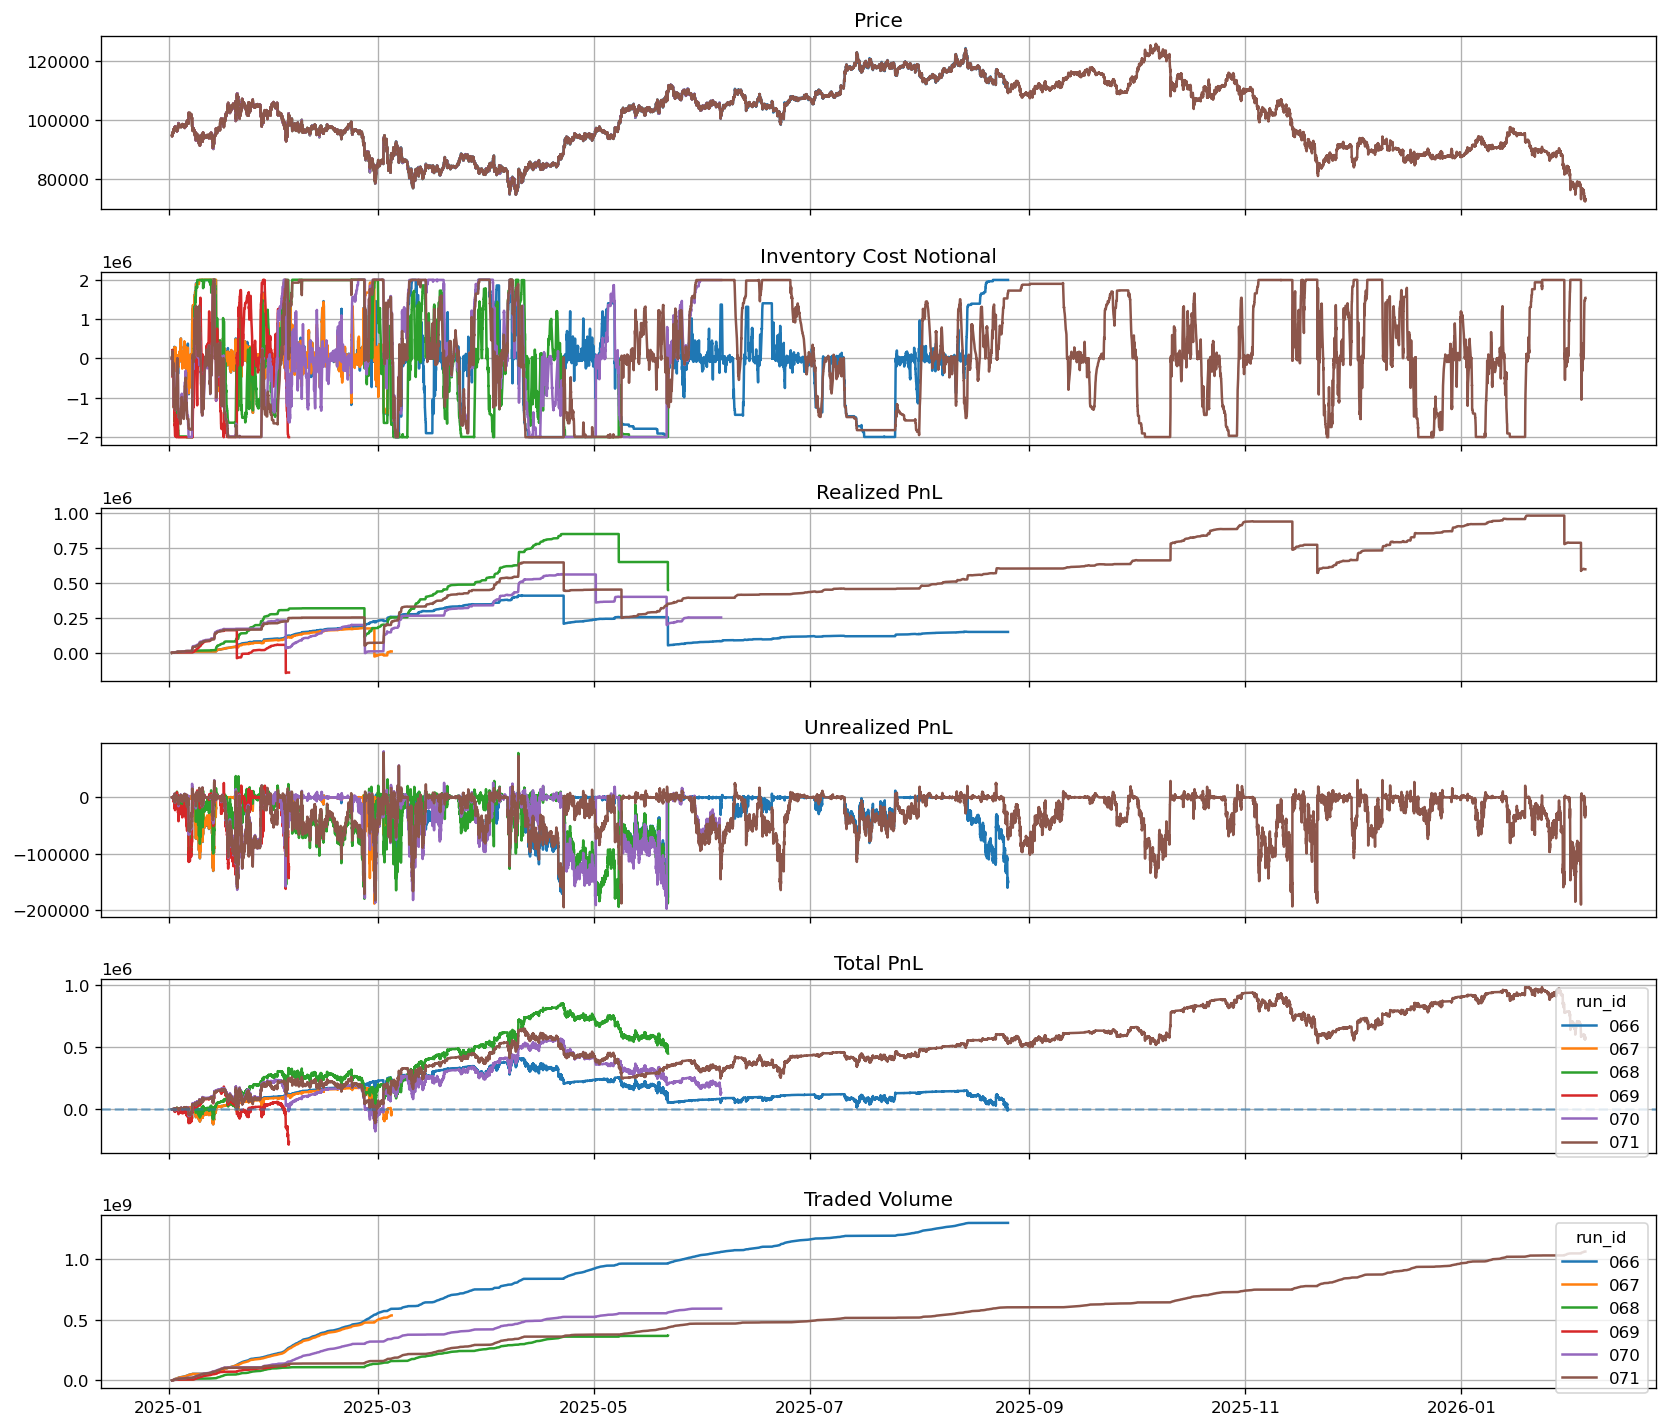

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,066,236,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-103.494465,-0.000837,-0.017780,410294.666970,-7.294901e+03,-0.017780,-0.000837,5.459966e+06,-7.980854e-08
1,067,62,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-22279.369157,-0.016778,-0.615704,262215.861344,-1.614474e+05,-0.615704,-0.016778,8.558433e+06,-4.161976e-05
2,068,140,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,449545.914227,0.082669,2.960404,401151.334199,1.187570e+06,2.960404,0.082669,2.614235e+06,1.218106e-03
3,069,33,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-265975.729597,-0.125139,-7.069135,420090.460675,-2.969676e+06,-7.069135,-0.125139,3.813295e+06,-2.088592e-03
4,070,155,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,135003.623649,0.021772,0.727840,428662.977955,3.119981e+05,0.727840,0.021772,3.781107e+06,2.283157e-04
5,071,399,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,579443.030380,0.043504,1.306116,404430.606507,5.282332e+05,1.306116,0.043504,2.643221e+06,5.461658e-04


batch 13: run_id 072..077


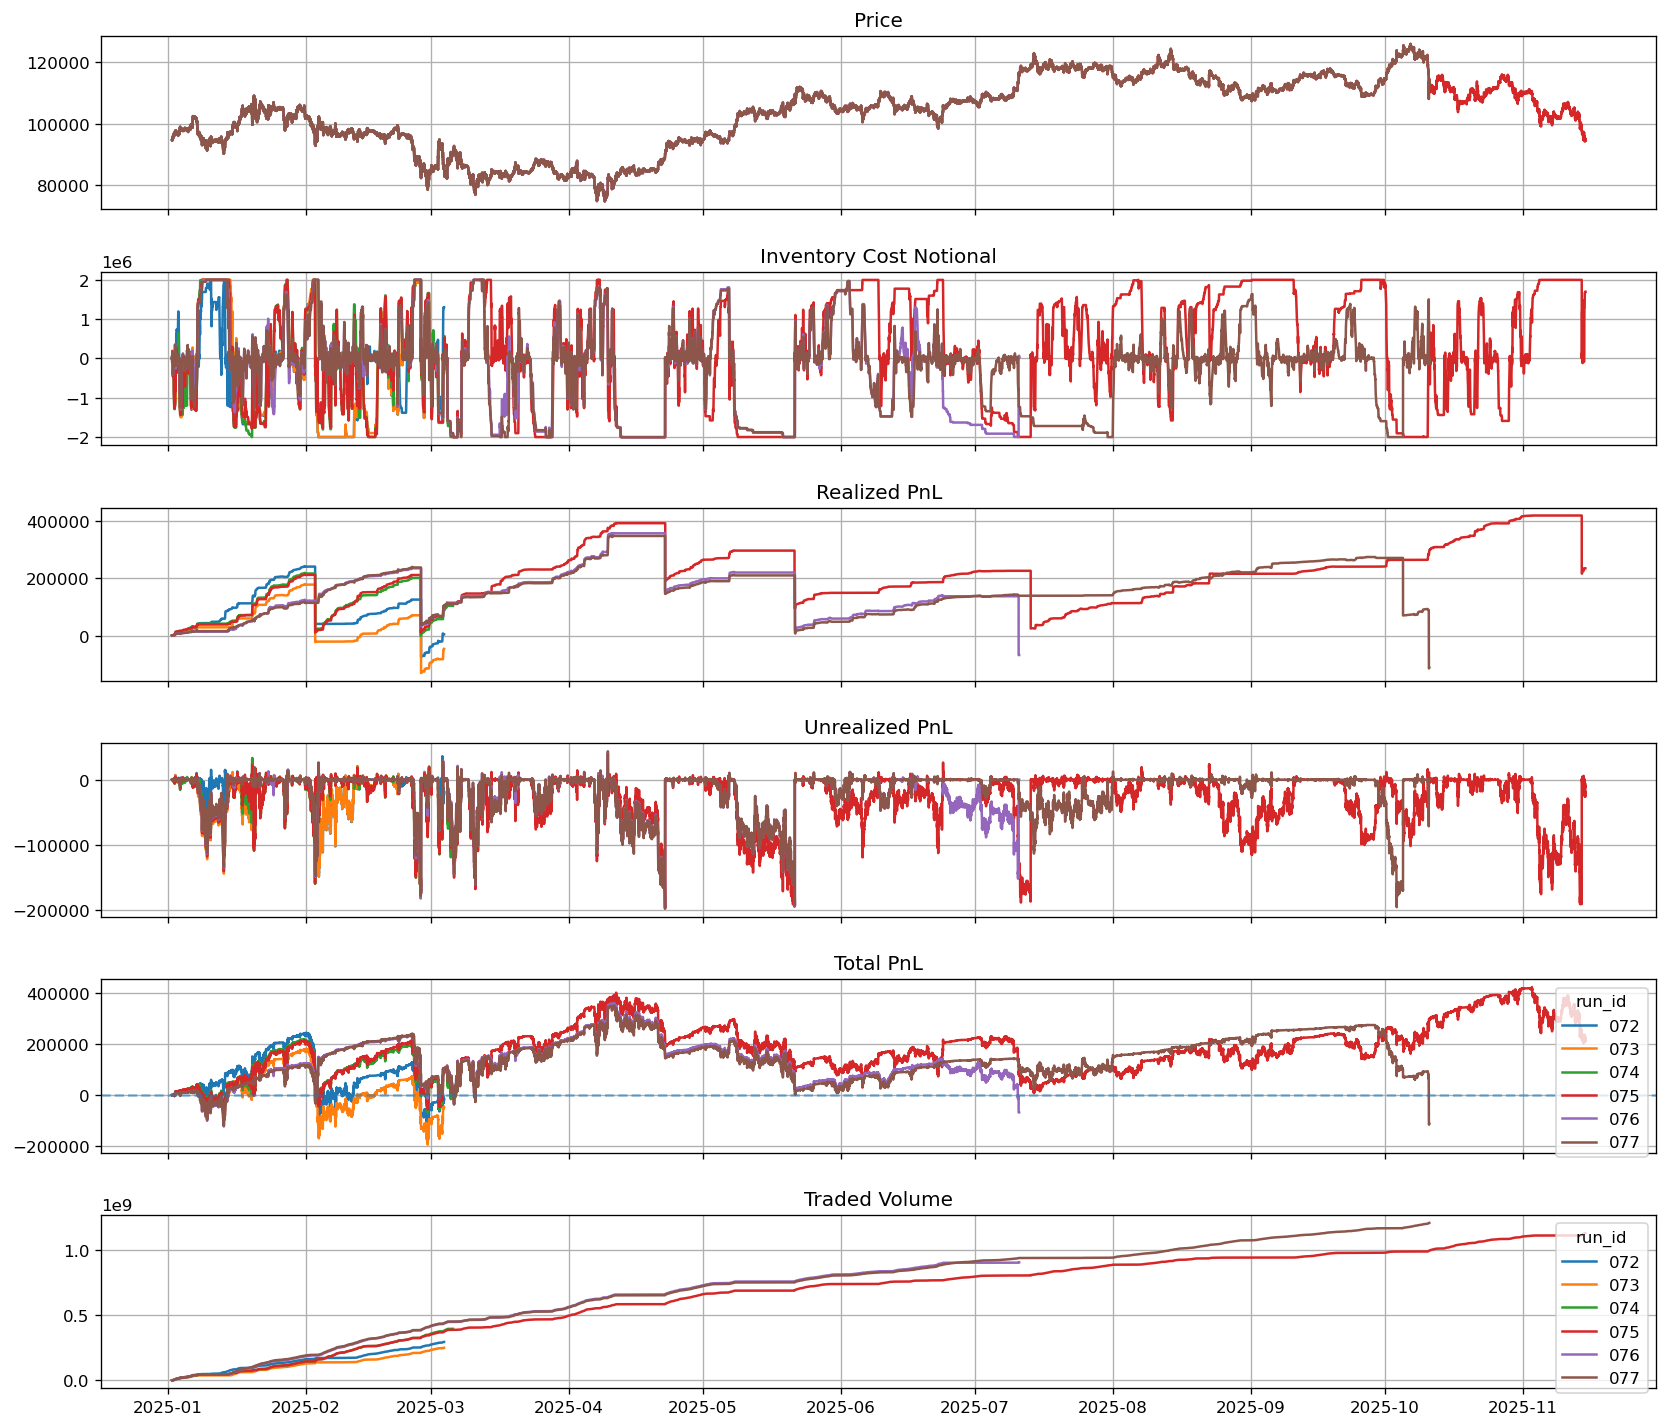

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,072,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-18782.880606,-0.011095,-0.549237,328851.003675,-180617.293607,-0.549237,-0.011095,4.729123e+06,-0.000064
1,073,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-46479.347072,-0.020242,-1.037330,339783.327132,-352467.313915,-1.037330,-0.020242,3.984836e+06,-0.000186
2,074,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-12402.143738,-0.009920,-0.579321,262854.608274,-152277.275618,-0.579321,-0.009920,6.157883e+06,-0.000031
3,075,317,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,214279.970700,0.020357,0.661222,350225.622336,231576.716947,0.661222,0.020357,3.523483e+06,0.000190
4,076,190,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-67892.557096,-0.013101,-0.338757,424034.476446,-143644.503166,-0.338757,-0.013101,4.725569e+06,-0.000075
5,077,282,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-112558.316064,-0.015287,-0.336081,459385.244489,-154390.676495,-0.336081,-0.015287,4.253927e+06,-0.000093


batch 14: run_id 078..079


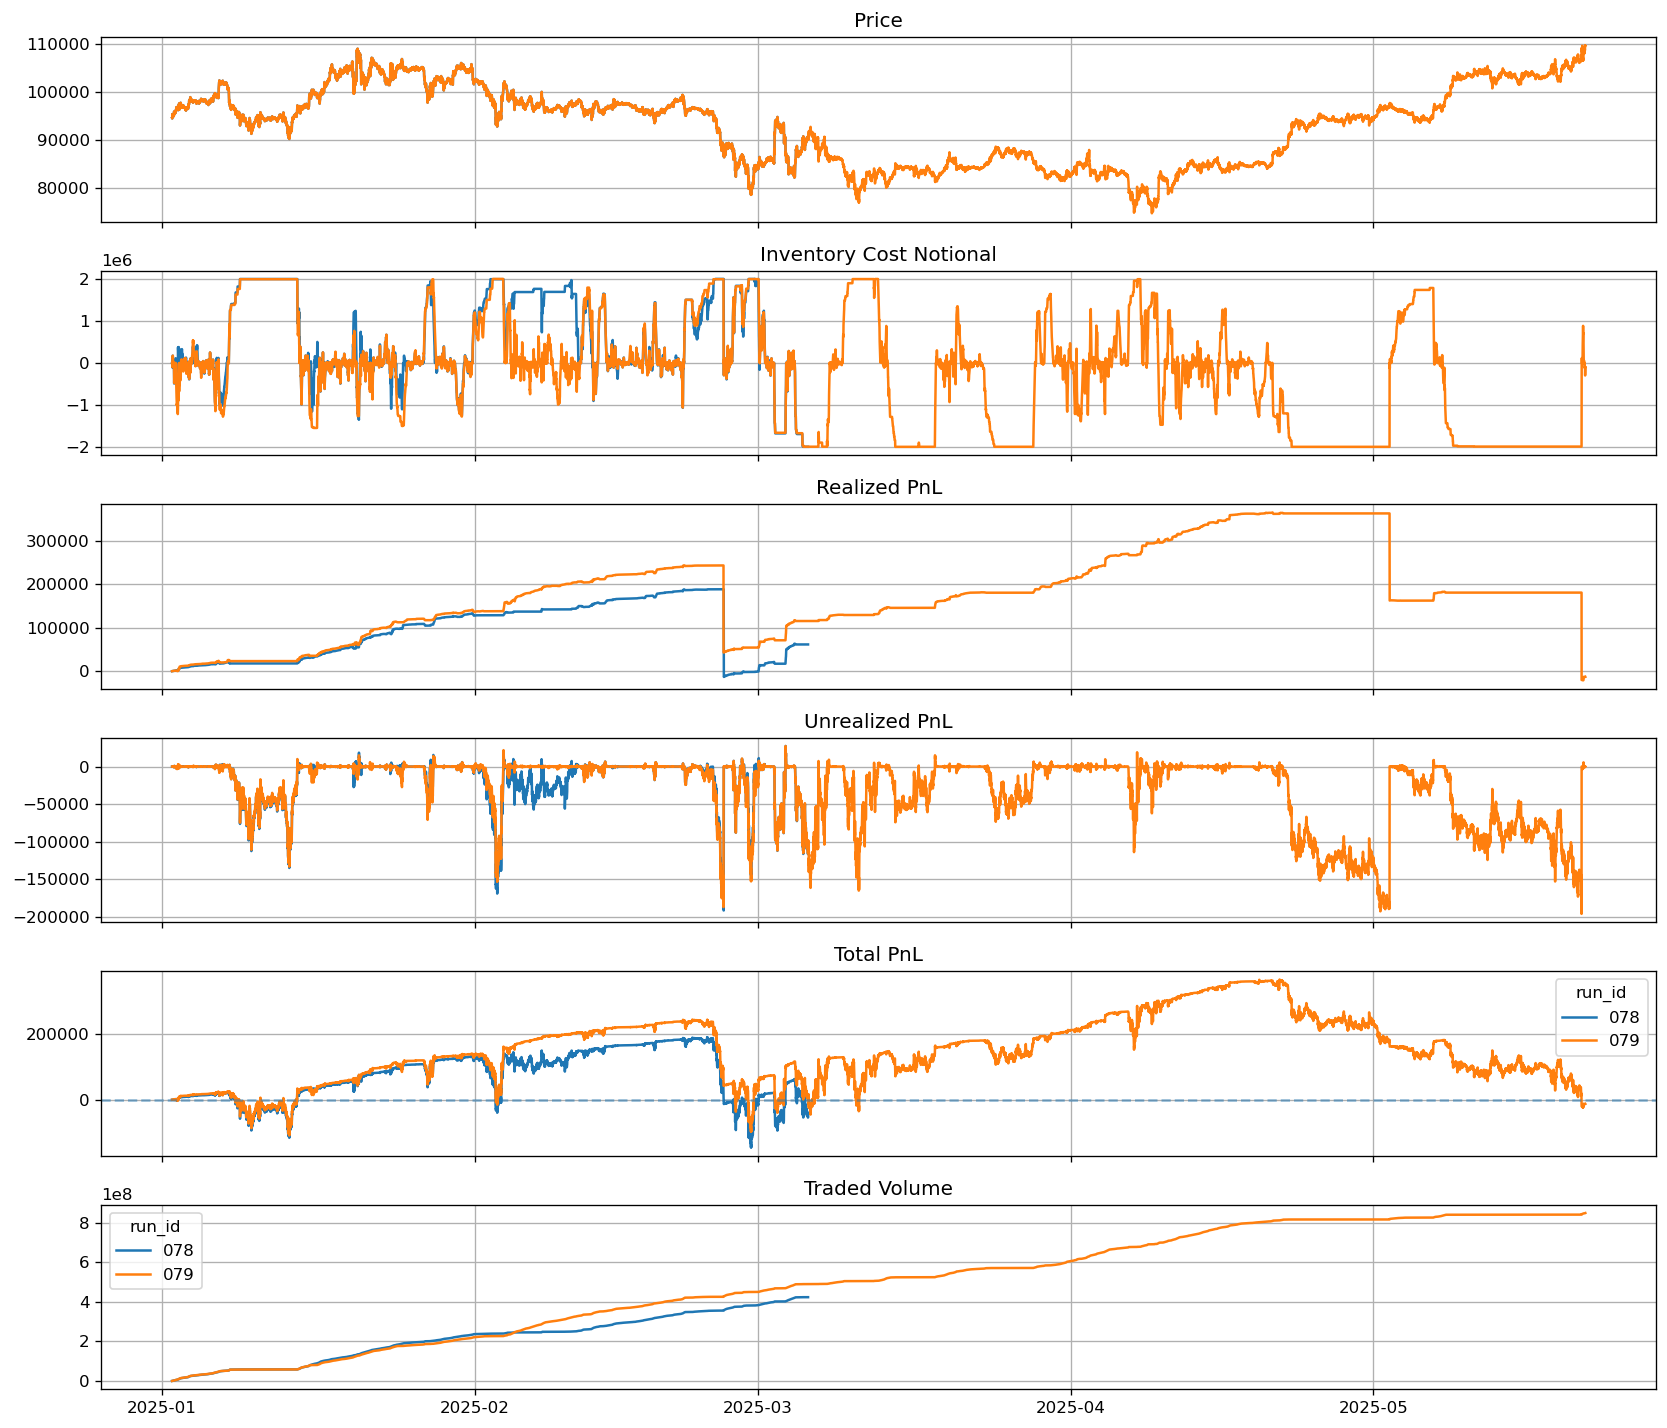

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,078,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-50757.584823,-0.025990,-1.269624,273382.083516,-347092.547717,-1.269624,-0.025990,6.604551e+06,-0.000120
1,079,140,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-13177.000465,-0.005194,-0.171501,378603.290351,-64930.855732,-0.171501,-0.005194,6.006275e+06,-0.000015


,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,032,326,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,880291.130594,0.074669,3.238797,295178.150713,9.560222e+05,3.238797,0.074669,1.035506e+07,2.573486e-04
1,035,400,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,741955.376532,0.045889,1.347836,487653.860901,6.572776e+05,1.347836,0.045889,1.072284e+07,1.719536e-04
2,031,397,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,737496.797831,0.050720,1.637753,400189.968148,6.554124e+05,1.637753,0.050720,9.668553e+06,1.903898e-04
3,046,326,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x15__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp15000...,649161.591438,0.069000,2.682009,265134.423513,7.110928e+05,2.682009,0.069000,9.415584e+06,2.091102e-04
4,071,399,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,579443.030380,0.043504,1.306116,404430.606507,5.282332e+05,1.306116,0.043504,2.643221e+06,5.461658e-04
5,011,464,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,571443.854508,0.032332,1.059135,408770.373816,4.329432e+05,1.059135,0.032332,6.127334e+06,1.998341e-04
6,010,400,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,492661.303184,0.031803,0.853626,504078.377552,4.302945e+05,0.853626,0.031803,6.052518e+06,2.020628e-04
7,068,140,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,449545.914227,0.082669,2.960404,401151.334199,1.187570e+06,2.960404,0.082669,2.614235e+06,1.218106e-03
8,063,398,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,415668.262586,0.029370,0.912900,404952.106195,3.696810e+05,0.912900,0.029370,1.539414e+07,6.739429e-05
9,008,400,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...,399206.023274,0.028201,0.692549,518485.071041,3.590763e+05,0.692549,0.028201,5.721648e+06,1.737693e-04


In [12]:
plot_df = choose_folders(limit=MAX_FOLDERS)
all_metrics = []

for start in range(0, len(plot_df), BATCH_SIZE):
    batch = plot_df.iloc[start : start + BATCH_SIZE]
    first_id = int(batch["run_id"].iloc[0])
    last_id = int(batch["run_id"].iloc[-1])
    print(f"batch {start // BATCH_SIZE + 1}: run_id {first_id:03d}..{last_id:03d}")
    all_metrics.append(plot_folder_batch(batch))

summary_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
display(summary_df.sort_values("pnls", ascending=False).reset_index(drop=True))

In [13]:
folders[31]

'/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__inkls__oc1x1x1__obom1__po1__pcp1200000__phmmarket__pp1__qp3__sm1____h6a09a49ab0/strat__all'

In [14]:
folders[35]

'/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__ink__oc1x1x1__obom1__po1__pcp1200000__phmmarket__pp1__qp3__sm1__sl200__hd74135becb/strat__all'

Inspect one folder with the full report panels.

Compare selected folders on one PnL chart.

In [ ]:

import pandas as pd
import numpy as np
import os
from glob import glob

base = "/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__ink__oc1x1x1__obom1__po1__pcp1200000__phmmarket__pp1__qp3__sm1__sl200__hd74135becb/strat__all"

files = sorted(glob(os.path.join(base, "*.parquet")))
print(f"Total daily files: {len(files)}")

# Read all daily files into one big DataFrame
dfs = []
for f in files:
    day = os.path.basename(f).replace('.parquet', '')
    df = pd.read_parquet(f)
    df['date'] = day
    dfs.append(df)

full = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(full)}")
print(f"Date range: {full['date'].min()} -> {full['date'].max()}")
print(f"Position range: {full['position'].min():.4f} -> {full['position'].max():.4f}")
print(f"Total PnL range: {full['total_pnl'].min():.2f} -> {full['total_pnl'].max():.2f}")
full.head()


In [ ]:

import json
import os
from glob import glob
import pandas as pd
import numpy as np

base = "/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__ink__oc1x1x1__obom1__po1__pcp1200000__phmmarket__pp1__qp3__sm1__sl200__hd74135becb/strat__all"

state_files = sorted(glob(os.path.join(base, "_state", "*.json")))
print(f"Total state files: {len(state_files)}")

records = []
for f in state_files:
    with open(f) as fh:
        s = json.load(fh)
    records.append({
        'day': os.path.basename(f).replace('.json', ''),
        'day_n': s.get('day_n'),
        'position': s['position']['qty'],
        'cost_notional': s['position']['cost_notional_usdt'],
        'mark_notional': s['position']['mark_notional_usdt'],
        'entry_price': s['position']['cost'] / s['position']['qty'] if s['position']['qty'] != 0 else None,
        'mid': s.get('phase_best_mid'),
        'realized_pnl': s['realized_pnl'],
        'unrealized_pnl': s['unrealized_pnl'],
        'total_pnl': s['total_pnl'],
        'max_pnl_ever': s.get('max_pnl_ever'),
        'traded_volume': s['traded_volume'],
        'phase_side': s.get('phase_side'),
    })

df = pd.DataFrame(records).sort_values('day_n')
df['drawdown_from_peak'] = df['total_pnl'] - df['max_pnl_ever']
df['drawdown_pct'] = df['drawdown_from_peak'] / 2000000 * 100

print(f"\nOverall stats:")
print(f"  Days: {len(df)}")
print(f"  Final total_pnl: {df['total_pnl'].iloc[-1]:.2f}")
print(f"  Peak total_pnl: {df['total_pnl'].max():.2f} on {df.loc[df['total_pnl'].idxmax(), 'day']}")
print(f"  Max drawdown: {df['drawdown_from_peak'].min():.2f} USDT ({df['drawdown_pct'].min():.1f}%)")
print(f"  Final position: {df['position'].iloc[-1]:.4f} BTC")

# Show key turning points
print("\n--- Top 10 PnL peaks ---")
peaks = df.nlargest(10, 'total_pnl')[['day', 'day_n', 'total_pnl', 'position', 'unrealized_pnl']]
print(peaks.to_string())

print("\n--- Top 10 PnL troughs ---")
troughs = df.nsmallest(10, 'drawdown_from_peak')[['day', 'day_n', 'total_pnl', 'drawdown_from_peak', 'drawdown_pct', 'position']]
print(troughs.to_string())
